<div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:200%; font-family:Arial, sans-serif; background-color:#404040; color:#1ED760; overflow:hidden; box-shadow:0 4px 8px rgba(0, 0, 0, 0.3); display: flex; align-items: center; justify-content: center;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/8/84/Spotify_icon.svg" alt="Spotify Logo" style="width:50px; height:50px; margin-right:10px;">
    <b>Lab 01: Phân tích thị trường âm nhạc tại Việt Nam</b>
</div>


#### Các thư viện cần thiết  
- **spotipy**: Thư viện để truy xuất dữ liệu từ **Spotify API**.    
- **requests, BeautifulSoup**: Gửi yêu cầu HTTP để lấy dữ liệu từ web, trích xuất dữ liệu từ HTML.
- **time**: Quản lý thời gian chạy khi gọi APIAPI thu thập dữ liệu.  
- **matplotlib**: Vẽ biểu đồ trực quan.  
- **seaborn**: Thư viện hỗ trợ vẽ biểu đồ đẹp.  
- **pandas**: Giúp xử lý và phân tích dữ liệu dạng DataFrame.  
- **numpy**: Xử lý dữ liệu số, hỗ trợ tính toán các giá trị thống kê.  
- **ast**: Chuyển chuỗi thành đối tượng Python, dùng trong `extract_genres_list` để trích xuất thể loại từ cột `genres`.  
- **circlify**: Tạo biểu đồ bong bóng để trực quan hóa.
- **warnings**: Ẩn cảnh báo khi chạy code, giúp bài trình bày sạch hơn.

In [1]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import requests
from bs4 import BeautifulSoup
import time

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import ast
import circlify

import warnings
warnings.filterwarnings('ignore')

<div style="text-align:left; border-radius:15px; padding:15px; margin:0; font-size:200%; font-family:Arial, sans-serif; background-color:#404040; color:#1ED760; box-shadow:0 4px 8px rgba(0, 0, 0, 0.3);">
  <b>Thu thập dữ liệu</b>
</div>


Quy trình bao gồm thu thập dữ liệu từ Kworb, Spotify và làm sạch dữ liệu

## 1. Thu thập thông tin những bài hát phổ biến nhất từ Kworb

Thu thập thông tin bài hát (artist, track name, streams,..) từ trang <a href="https://kworb.net/spotify/country/vn_weekly_totals.html">Kworb Spotify Charts</a>, đây là một trang web uy tín của bên thứ ba chuyên tổng hợp số liệu về lượt stream và xếp hạng tại khu vực Việt Nam.

Từ đây, nhóm em chọn lọc khoảng 3500 bài hát nổi bật nhất ở thị trường Việt Nam trong những năm gần đây cho đến hiện tại (đến 27/02/2025), đủ để phác họa bức tranh toàn cảnh về thị trường âm nhạc trực tuyến tại Việt Nam.

In [ ]:
url = "https://kworb.net/spotify/country/vn_weekly_totals.html"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
response.raise_for_status()  

soup = BeautifulSoup(response.content, 'html.parser')
tbody = soup.find('tbody')

rows = tbody.find_all('tr')[:3500]
data_list = []
for row in rows:
    artist = row.find('a', href=lambda x: x and 'artist' in x).text.strip()
    track = row.find('a', href=lambda x: x and 'track' in x).text.strip()

    tds = row.find_all('td')[1:]  
    wks = int(tds[0].text.strip()) if len(tds) > 0 and tds[0].text.strip().isdigit() else 0
    t10 = int(tds[1].text.strip()) if len(tds) > 0 and tds[1].text.strip().isdigit() else 0
    pk_rank = int(tds[2].text.strip()) if len(tds) > 0 and tds[2].text.strip().isdigit() else 0
    pk_streams = int(tds[4].text.replace(',', '').strip()) if len(tds) > 0 and tds[4].text.strip() else 0
    total_streams = int(tds[5].text.replace(',', '').strip()) if len(tds) > 0 and tds[5].text.strip() else 0

    data_list.append({
        "artist": artist,
        "track": track,
        "wks": wks,
        "t10": t10,
        "pk_rank": pk_rank,
        "pk_streams": pk_streams,
        "total_streams": total_streams
    })

data_df = pd.DataFrame(data_list)
data_df.to_csv('Data/raw_data/kworb_data.csv', index=False, sep='\t')
print(data_df.shape)

(3500, 7)


Để dữ liệu được chính xác hơn, loại bỏ hàng thiếu dữ liệu và trùng lặp dựa trên artist và track.

In [2]:
kworb_df = pd.read_csv('Data/raw_data/kworb_data.csv', sep = '\t')

# loại bỏ các hàng có dữ liệu bị thiếu, có track và artist trùng nhau
kworb_df.dropna(inplace=True)
kworb_df.drop_duplicates(subset=['artist', 'track'], inplace=True)
kworb_df.to_csv('Data/raw_data/kworb_data.csv', index=False, sep='\t')
print('Kích thước dữ liệu từ Kworb sau khi đã xử lý: ', kworb_df.shape)
kworb_df.head()

Kích thước dữ liệu từ Kworb sau khi đã xử lý:  (3419, 7)


,artist,track,wks,t10,pk_rank,pk_streams,total_streams
0,Jung Kook,Seven,84,84,1,7520027,200422960
1,Jimin,Like Crazy,75,67,1,2279475,80209862
2,Jung Kook,Standing Next to You,67,56,1,2668061,79103189
3,Jimin,Who,31,30,1,4621573,68731532
4,V,Love Me Again,70,50,2,1907238,54773344


Để lấy thông tin từng bài hát một cách chính xác từ Spotify API, thực hiện ghép cột track và artist từ `kworb_df` thành danh sách các tuple (track, artist) để gửi yêu cầu đến Spotify API.

In [3]:
track_artist = list(zip(kworb_df['track'].tolist(), kworb_df['artist'].tolist()))
print(track_artist[:5])

[('Seven', 'Jung Kook'), ('Like Crazy', 'Jimin'), ('Standing Next to You', 'Jung Kook'), ('Who', 'Jimin'), ('Love Me Again', 'V')]


## 2 Thu thập thông tin chi tiết từ Spotify API

Sử dụng thư viện Spotipy kết hợp với `track_artist` đã được xử lí ở trên để lấy thông tin chi tiết (album, genres, popularity,...) từ Spotify.

Dữ liệu sau khi được thu thập từ Spotify về được lưu trong `spotify_tracks.csv`

In [ ]:
client_id = "e2443bce7fab40c0bff9a14503cf1a38"
client_secret = "27aece0067c746b88afc445fefe5f3c0"

auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
spotify = spotipy.Spotify(auth_manager=auth_manager)

artist_cache = {}
def get_track_info(track):
    """
    Lấy thông tin của track từ Spotify.
    """
    try:
        artist = track['artists'][0]
        artist_name = artist['name']
        
        if artist['id'] not in artist_cache:
            artist_info = spotify.artist(artist['id'])
            artist_cache[artist['id']] = artist_info['genres']
        
        genres = artist_cache[artist['id']]
        
        track_info = {
            'track_name': track['name'],
            'album_name': track['album']['name'],
            'artist_name': artist_name,
            'genres': genres,
            'release_date': track['album']['release_date'],
            'duration_ms': track['duration_ms'],
            'popularity': track['popularity'],
            'explicit': track['explicit'],
            'is_playable': track.get('is_playable', True)
        }
        return track_info
    except Exception as e:
        print(f"Error processing track: {e}")
        return None
    
def search_track(track_name, artist_name):
    """
    Tìm kiếm thông tin của track và artist tương ứng trên Spotify.
    """
    try:
        query = f"track:{track_name} artist:{artist_name}"
        result = spotify.search(q=query, type='track', limit=1)
        
        if result['tracks']['items']:
            track = result['tracks']['items'][0]
            return get_track_info(track)
        return None
    except Exception as e:
        print(f"Error searching for {track_name} by {artist_name}: {e}")
        return None

# Lấy thông tin của các bài hát từ Spotify
batch_size = 50
tracks = []
total_tracks = len(track_artist)

for i in range(0, total_tracks, batch_size):
    print(f"Processing batch {i//batch_size + 1}/{(total_tracks + batch_size - 1)//batch_size}")
    batch = track_artist[i:i + batch_size]
    for track_name, artist_name in batch:
        track_info = search_track(track_name, artist_name)
        if track_info:
            tracks.append(track_info)
        else:
            print(f"Could not find track: {track_name} by {artist_name}")
            tracks.append({
                'track_name': track_name,
                'album_name': None,
                'artist_name': artist_name,
                'genres': None,
                'release_date': None,
                'duration_ms': None,
                'popularity': None,
                'explicit': None,
                'is_playable': None
            })
    time.sleep(2)


spotify_df = pd.DataFrame(tracks)
print(f"Successfully retrieved {len(tracks)} tracks out of {total_tracks} attempts")
spotify_df.to_csv('Data/raw_data/spotify_tracks.csv', index=False, sep='\t', encoding='utf-8-sig')

Processing batch 1/69
Processing batch 2/69
Processing batch 3/69
Could not find track: Đánh Đổi (ft. RPT MCK) by Obito
Could not find track: Hà Nội (ft. VSTRA) by Obito
Could not find track: Ghé Qua by TaynguyenSound
Processing batch 4/69
Processing batch 5/69
Could not find track: Diamond Cut Diamond by Hoàng Thùy Linh
Could not find track: I Am Not Thuy Kieu by Hoàng Thùy Linh
Processing batch 6/69
Could not find track: Tell the kids i love them (ft. Shiki) by Obito
Processing batch 7/69
Processing batch 8/69
Could not find track: Love of Ghosts by Hoàng Thùy Linh
Could not find track: Đầu Đường Xó Chợ (ft. Lăng LD) by Obito
Processing batch 9/69
Could not find track: Đi Giữa Trời Rực Rỡ (Original Soundtrack from “Đi Giữa Trời Rực Rỡ”) by SK Pictures
Could not find track: Girl Hà Nội (ft. Dangrangto, Lu, Rem) by SIXTYUPTOWN
Processing batch 10/69
Processing batch 11/69
Could not find track: Lời Đường Mật by Artist Page Redirect Cleanup 2023
Processing batch 12/69
Processing batch 13

Kiểm tra dữ liệu sau khi thu thập từ Spotify

In [4]:
spotify_df = pd.read_csv('Data/raw_data/spotify_tracks.csv', sep = '\t')
print(spotify_df.shape)
spotify_df.head()

(3419, 9)


,track_name,album_name,artist_name,genres,release_date,duration_ms,popularity,explicit,is_playable
0,Seven (feat. Latto) (Explicit Ver.),GOLDEN,Jung Kook,['k-pop'],2023-11-03,183550.0,81.0,True,True
1,Like Crazy,FACE,Jimin,['k-pop'],2023-03-24,212241.0,71.0,False,True
2,Standing Next to You,GOLDEN,Jung Kook,['k-pop'],2023-11-03,206019.0,82.0,False,True
3,Who,MUSE,Jimin,['k-pop'],2024-07-19,170887.0,87.0,False,True
4,Love Me Again,Layover,V,['k-pop'],2023-08-11,182293.0,72.0,False,True


## 3. Thực hiện kết hợp dữ liệu có được từ Kworb và Spotify API thành bộ dữ liệu hoàn chỉnh

Trước khi ghép, kiểm tra index của `spotify_df` và `kworb_df` để đảm bảo dữ liệu được nối đúng thứ tự. Việc giữ đúng thứ tự là cần thiết vì mỗi dòng dữ liệu (tương ứng với một bài hát) từ Spotify được lấy theo danh sách track-artist từ Kworb. Nếu thứ tự bị lệch, thông tin các bài hát sẽ không khớp nhau.

In [5]:
print(spotify_df.index)
print(kworb_df.index)

RangeIndex(start=0, stop=3419, step=1)
RangeIndex(start=0, stop=3419, step=1)


Ghép các tập dữ liệu từ `spotify_df` và `kworb_df` theo index tương ứng với track và artist.

In [6]:
merged_df = pd.concat([spotify_df, kworb_df], axis=1)
merged_df.to_csv('Data/raw_data/merged_data.csv', index=False, sep='\t', encoding='utf-8-sig')
print('Dữ liệu sau khi merge: ', merged_df.shape)
merged_df.head()

Dữ liệu sau khi merge:  (3419, 16)


,track_name,album_name,artist_name,genres,release_date,duration_ms,popularity,explicit,is_playable,artist,track,wks,t10,pk_rank,pk_streams,total_streams
0,Seven (feat. Latto) (Explicit Ver.),GOLDEN,Jung Kook,['k-pop'],2023-11-03,183550.0,81.0,True,True,Jung Kook,Seven,84,84,1,7520027,200422960
1,Like Crazy,FACE,Jimin,['k-pop'],2023-03-24,212241.0,71.0,False,True,Jimin,Like Crazy,75,67,1,2279475,80209862
2,Standing Next to You,GOLDEN,Jung Kook,['k-pop'],2023-11-03,206019.0,82.0,False,True,Jung Kook,Standing Next to You,67,56,1,2668061,79103189
3,Who,MUSE,Jimin,['k-pop'],2024-07-19,170887.0,87.0,False,True,Jimin,Who,31,30,1,4621573,68731532
4,Love Me Again,Layover,V,['k-pop'],2023-08-11,182293.0,72.0,False,True,V,Love Me Again,70,50,2,1907238,54773344


Để đảm bảo tính chính xác của dữ liệu sau khi ghép lại với nhau, nhóm em sẽ kiểm tra lại `track_name` và `artist_name` (từ spotify_df) và `track` và `artist` (từ kworb_df) tương ứng trên mỗi hàng của dữ liệu có giống nhau không.

In [7]:
def check_feature_similarity(feature1, feature2):
    """ 
    Hàm kiểm tra 2 feature có giống nhau không
    """
    if feature1 == feature2:
        return True
    return False

# kiểm tra 2 feature có giống nhau không
count = 0
for i in range(merged_df.shape[0]):
    if check_feature_similarity(merged_df['artist'][i], merged_df['artist_name'][i]):
        count += 1
    else:
        print (f"{merged_df['artist'][i]} and {merged_df['artist_name'][i]}")
print(f"Có {count} hàng dữ liệu trùng khớp nhau")

NÂN and Ngơ
TaynguyenSound and Tùng TeA
JustaTee and Hoàng Thùy Linh
Hoang Dung and Hoàng Dũng
Amee and Ricky Star
11:11 Music Group and Jasper
Tia and TIA
K-ICM and Hồ Tuấn Phúc
MANBO and HIEUTHUHAI
K-ICM and ICM
Lãng and Mike
TIA and fueled by boba
GONZO and Gonzo
TaynguyenSound and Tùng TeA
Masew and Xesi
K-ICM and ICM
Tiên Fami and Đoàn Minh Quân
Arcane and Stromae
Miina and MiiNa
Freak D and Tân Trần
Khói and Châu Đăng Khoa
JGKiD (Da LAB) and Da LAB
K-391 and Alan Walker
CARA and Caravan
K-ICM and ICM
Chu Thúy Quỳnh and CaoTri
tlinh and SOOBIN
Cukak and buitruonglinh
World the Kid and Velvet Horizon
Sol Silva and Solsilva
Masiu and Masew
Mr T and YanBi
BTS and Charlie Puth
Demi Lovato and Jax Jones
LyLy and Lyly
K-ICM and VINA BẤT DIỆT
Nguyễn Đình Vũ and Qinn Media
YanBi and Hoàng Tôn
Emcee L (Da LAB) and Da LAB
OneRepublic and Timbaland
JustaTee and BigDaddy
Hứa Kim Tuyền and Forest Studio
takayan and たかやん
Nguyễn Trần Trung Quân and Studio Số 6
Emily and BigDaddy
M.E.R and Mer
Na

Kết quả cho thấy 3366 hàng khớp nhau, nhưng vẫn có vài trường hợp khác. Lý do là một bài hát có thể có nhiều nghệ sĩ (mà ở đây nhóm chỉ lấy nghệ sĩ đầu tiên từ Spotify) hoặc do định dạng chữ không khớp (ví dụ: "K-ICM" và "ICM"). Vì vậy, dữ liệu chính vẫn đúng nên nhóm quyết định giữ lại các bài hát này.

Sau khi kiểm tra, loại bỏ các cột `artist` và `track`, giữ lại `track_name` và `artist_name`

Cuối cùng, lưu dữ liệu thô thu thập đã được xử lí cơ bản vào `merged_data.csv` cho việc xử lí và khám phá.

In [8]:
merged_df.drop(columns=['artist', 'track'], inplace = True)
merged_df.to_csv('Data/raw_data/merged_data.csv', index=False, sep='\t', encoding='utf-8-sig')
print('Dữ liệu sau khi xử lý cơ bản: ', merged_df.shape)
merged_df.head()

Dữ liệu sau khi xử lý cơ bản:  (3419, 14)


,track_name,album_name,artist_name,genres,release_date,duration_ms,popularity,explicit,is_playable,wks,t10,pk_rank,pk_streams,total_streams
0,Seven (feat. Latto) (Explicit Ver.),GOLDEN,Jung Kook,['k-pop'],2023-11-03,183550.0,81.0,True,True,84,84,1,7520027,200422960
1,Like Crazy,FACE,Jimin,['k-pop'],2023-03-24,212241.0,71.0,False,True,75,67,1,2279475,80209862
2,Standing Next to You,GOLDEN,Jung Kook,['k-pop'],2023-11-03,206019.0,82.0,False,True,67,56,1,2668061,79103189
3,Who,MUSE,Jimin,['k-pop'],2024-07-19,170887.0,87.0,False,True,31,30,1,4621573,68731532
4,Love Me Again,Layover,V,['k-pop'],2023-08-11,182293.0,72.0,False,True,70,50,2,1907238,54773344


<div style="text-align:left; border-radius:15px; padding:15px; margin:0; font-size:200%; font-family:Arial, sans-serif; background-color:#404040; color:#1ED760; box-shadow:0 4px 8px rgba(0, 0, 0, 0.3);">
  <b>Tiền xử lí và khám phá dữ liệu</b>
</div>

Ở phần này nhóm sẽ làm sạch dữ liệu và tìm hiểu đặc điểm ban đầu để chuẩn bị cho phân tích, qua đó có cái nhìn tổng quan ban đầu về bộ dữ liệu cũng như thị trường âm nhạc Việt Nam

Đọc dữ liệu từ tệp **merged_data.csv** vào DataFrame là `music_df`.

In [9]:
music_df = pd.read_csv('Data/raw_data/merged_data.csv', encoding='utf-8', delimiter='\t', low_memory=False)
music_df.head(5)

,track_name,album_name,artist_name,genres,release_date,duration_ms,popularity,explicit,is_playable,wks,t10,pk_rank,pk_streams,total_streams
0,Seven (feat. Latto) (Explicit Ver.),GOLDEN,Jung Kook,['k-pop'],2023-11-03,183550.0,81.0,True,True,84,84,1,7520027,200422960
1,Like Crazy,FACE,Jimin,['k-pop'],2023-03-24,212241.0,71.0,False,True,75,67,1,2279475,80209862
2,Standing Next to You,GOLDEN,Jung Kook,['k-pop'],2023-11-03,206019.0,82.0,False,True,67,56,1,2668061,79103189
3,Who,MUSE,Jimin,['k-pop'],2024-07-19,170887.0,87.0,False,True,31,30,1,4621573,68731532
4,Love Me Again,Layover,V,['k-pop'],2023-08-11,182293.0,72.0,False,True,70,50,2,1907238,54773344


## 1. Kích thước dữ liệu

In [10]:
music_nrows = music_df.shape[0]
music_ncols = music_df.shape[1]

print("Số dòng của dữ liệu:", music_nrows)
print("Số cột của dữ liệu:", music_ncols)

Số dòng của dữ liệu: 3419
Số cột của dữ liệu: 14


## 2. Ý nghĩa của dữ liệu
### 2.1. Các hàng
Trước tiên, kiểm tra xem có dòng dữ liệu nào bị trùng không.

In [11]:
duplicate_music = music_df.duplicated().sum()
print("Số dòng dữ liệu trùng nhau:", duplicate_music)

Số dòng dữ liệu trùng nhau: 0


Như vậy, có các thông tin sau:
   - Có tổng cộng **3419** bài nhạc và **14** trường thông tin.
   - Mỗi dòng trong dữ liệu này chứa thông tin về một bài nhạc tương ứng với tên, ngày phát hành, thể loại, tên album, độ nổi tiếng, lượt streams,...
   - Vì không có dòng nào bị trùng trong dataFrame nên nhóm em sẽ tiếp tục thực hiện bước tiếp theo.

### 2.2. Các cột
Tiếp theo, xem qua tên của các cột trong từng tệp dữ liệu:

In [12]:
print('Các trường thông tin của dữ liệu:')
print(pd.Series(music_df.columns).to_string())

Các trường thông tin của dữ liệu:
0        track_name
1        album_name
2       artist_name
3            genres
4      release_date
5       duration_ms
6        popularity
7          explicit
8       is_playable
9               wks
10              t10
11          pk_rank
12       pk_streams
13    total_streams


Dựa trên tên của các cột trong `music_df`, ý nghĩa của các cột như sau:

- `track_name`: Tên bài hát.
- `album_name`: Tên album của bài hát đó.
- `artist_name`: Tên nghệ sĩ hoặc ban nhạc thể hiện bài hát.
- `genres`: Thể loại nhạc của bài hát.
- `release_date`: Ngày phát hành của bài hát.
- `duration_ms`: Thời lượng của bài hát, tính bằng mili giây.
- `popularity`: Mức độ phổ biến của bài hát, được tính trên phạm vi toàn cầu (0-100).
- `explicit`: Chỉ định xem bài hát có nội dung nhạy cảm (Explicit) hay không.
- `is_playable`: Cho biết bài hát có thể phát được hay không.
- `wks`: Số tuần bài hát xuất hiện trên bảng xếp hạng (ở khu vực Việt Nam).
- `t10`: Số lần bài hát lọt vào top 10 của bảng xếp hạng (ở khu vực Việt Nam).
- `pk_rank`: Xếp hạng cao nhất mà bài hát từng đạt được (ở khu vực Việt Nam).
- `pk_streams`: Số lượt phát cao nhất mà bài hát từng đạt trong một khoảng thời gian nhất định (ở khu vực Việt Nam).
- `total_streams`: Tổng số lượt phát của bài hát (ở khu vực Việt Nam).

Trước khi tiến hành phân tích, nhóm đã thống nhất loại bỏ các cột không có ý nghĩa đối với mục tiêu nghiên cứu, cụ thể:  

- **Cột `is_playable`**: Chỉ thể hiện bài hát có thể phát trên Spotify hay không, không đóng góp giá trị phân tích trong việc đánh giá xu hướng âm nhạc.  
- **Cột `popularity`**: Đây là chỉ số do Spotify cung cấp, được tính dựa trên số lượt nghe toàn cầu. Do đó, việc sử dụng cột này không phản ánh chính xác xu hướng của riêng tại thị trường âm nhạc tại Việt Nam.

Do đó, nhóm sẽ xóa các cột `is_playable` và `popularity`.

In [13]:
music_df.drop(['is_playable'], axis=1, inplace=True)
music_df.drop(['popularity'], axis=1, inplace=True)

## 3. Kiểm tra dữ liệu

Sau khi hiểu được ý nghĩa của các cột, nhóm em sẽ tiếp tục kiểm tra kiểu dữ liệu của chúng để xem xét cần chuyển đổi kiểu dữ liệu nào không nếu chúng chưa hợp lí.

In [14]:
print('Kiểu dữ liệu của các cột trong bộ dữ liệu:')
print(pd.Series(music_df.dtypes).to_string())

Kiểu dữ liệu của các cột trong bộ dữ liệu:
track_name        object
album_name        object
artist_name       object
genres            object
release_date      object
duration_ms      float64
explicit          object
wks                int64
t10                int64
pk_rank            int64
pk_streams         int64
total_streams      int64


Như ta có thể thấy ở trên, các cột có kiểu dữ liệu gần đúng như mong đợi, có thể sẽ cần chuyển đổi kiểu dữ liệu của một số cột. Ví dụ, cột `release_date` nên chuyển sang kiểu datetime để dễ dàng xử lý, các thông tin có kiểu là object thường là dạng string và có thể chứa các giá trị `NaN` hoặc `None` nên cần xử lý trước khi chuyển đổi kiểu dữ liệu.

Nhóm em sẽ tiến hành kiểm tra các giá trị làm cho các cột không thể chuyển đổi sang kiểu dữ liệu đúng của nó. Đồng thời, sẽ xem xét các giá trị `NaN`, bị thiếu trong dữ liệu.

### 3.1. Kiểm tra dữ liệu bị thiếu

In [15]:
print(music_df.isnull().sum().to_string())
print('-'*30)
print('Tổng số dòng \t\t', music_df.shape[0])

track_name         0
album_name       147
artist_name        0
genres           146
release_date     146
duration_ms      146
explicit         146
wks                0
t10                0
pk_rank            0
pk_streams         0
total_streams      0
------------------------------
Tổng số dòng 		 3419


Như vậy, các cột có kiểu giá trị là số không có bất kì dữ liệu bị thiếu nào, trong khi đó các cột có giá trị bị thiếu là các cột phân loại bao gồm: `album_name`, `genres`, `release_date`, `duration_ms` và `explicit`, đồng thời chúng có tỉ lệ bị thiếu khá thấp. Cụ thể:
- `album_name`: 0.04%
- `genres`: 0.04%
- `release_date`: 0.04%
- `duration_ms`: 0.04%
- `explicit`: 0.04%

Mặc dù các thông tin bị thiếu không quá nhiều tuy nhiên cũng cần phải quan tâm rằng các giá trị `NaN` này có thể ảnh hưởng đến kết quả của việc phân tích. Do đó, nhóm em sẽ xử lý các giá trị `NaN` này ở bước tiếp theo.

In [16]:
missing_data_df = music_df[music_df.isnull().any(axis=1)]
print('Số dòng dữ liệu bị thiếu:', missing_data_df.shape[0])
print('Dữ liệu bị thiếu:')
missing_data_df.head()

Số dòng dữ liệu bị thiếu: 147
Dữ liệu bị thiếu:


,track_name,album_name,artist_name,genres,release_date,duration_ms,explicit,wks,t10,pk_rank,pk_streams,total_streams
131,Đánh Đổi (ft. RPT MCK),NaN,Obito,NaN,NaN,NaN,NaN,39,2,7,634920,15243260
135,Hà Nội (ft. VSTRA),NaN,Obito,NaN,NaN,NaN,NaN,39,1,10,524339,14774525
139,Ghé Qua,NaN,TaynguyenSound,NaN,NaN,NaN,NaN,150,0,64,245075,14500249
208,Diamond Cut Diamond,NaN,Hoàng Thùy Linh,NaN,NaN,NaN,NaN,128,16,1,159492,9340096
248,I Am Not Thuy Kieu,NaN,Hoàng Thùy Linh,NaN,NaN,NaN,NaN,127,13,1,210493,7678762


Qua quan sát, nhóm em nhận thấy hầu hết các trường dữ liệu bị thiếu đều thuộc về một số bài hát nhất định. Vấn đề này có thể xảy ra trong quá trình thu thập dữ liệu từ API của Spotify, có thể do lỗi truy xuất hoặc do Spotify không cung cấp đầy đủ thông tin cho những bài hát này.  

Tuy nhiên, vì số lượng bài hát có dữ liệu không đầy đủ này chiếm tỉ lệ rất nhỏ so với toàn bộ tập dữ liệu, nên để đảm bảo chất lượng phân tích, nhóm quyết định **loại bỏ những bài hát này khỏi tập dữ liệu chính.**

In [17]:
music_df.dropna(inplace=True)
print('Số dòng dữ liệu sau khi xử lý:', music_df.shape[0])

Số dòng dữ liệu sau khi xử lý: 3272


### 3.2. Đối với dữ liệu thời gian

Tiếp theo, xem xét cột `release_date` và xem có giá trị nào bất thường không.

In [18]:
invalid_release_date = music_df[~pd.to_datetime(music_df['release_date'], errors='coerce').notnull()]
print('Số dòng chứa giá trị release_date không hợp lệ:', invalid_release_date.shape[0])
print('Các giá trị release_date không hợp lệ:')
print(invalid_release_date['release_date'].unique())

Số dòng chứa giá trị release_date không hợp lệ: 25
Các giá trị release_date không hợp lệ:
['2019' '2016' '2020' '2018' '2015' '2017' '1980' '2008' '2021' '2006'
 '1963' '1945' '2010']


Các giá trị như `2016`, `2020`, `2018`,.. trong `release_date` không hợp lý vì thiếu tháng và ngày, không đồng nhất với định dạng `YYYY-MM-DD`. Nguyên nhân có thể là Spotify chỉ cung cấp thông tin năm cho một số bài hát, không đầy đủ như các bài hát còn lại. Và vì tỉ lệ của chúng cũng rất ít nên nhóm cũng quyết định **bỏ đi các dòng dữ liệu này.**

Nhóm em sẽ chuyển cột `release_date` thành datetime để dễ dàng xử lý và sẽ loại bỏ đi những hàng có giá trị không hợp lý này.

In [19]:
music_df = music_df[pd.to_datetime(music_df['release_date'], errors='coerce').notnull()]
music_df['release_date'] = pd.to_datetime(music_df['release_date'])
print(music_df['release_date'].dtypes)

datetime64[ns]


Bên cạnh đó, nhóm em cũng thực hiện kiểm tra lại các mốc thời gian phát hành của các bài hát trong tập dữ liệu thông qua biểu đồ histogram dưới đây để xem có điều gì bất thường không.

Ngày phát hành lâu nhất: 1900-01-01 00:00:00
Ngày phát hành gần đây nhất: 2025-02-24 00:00:00


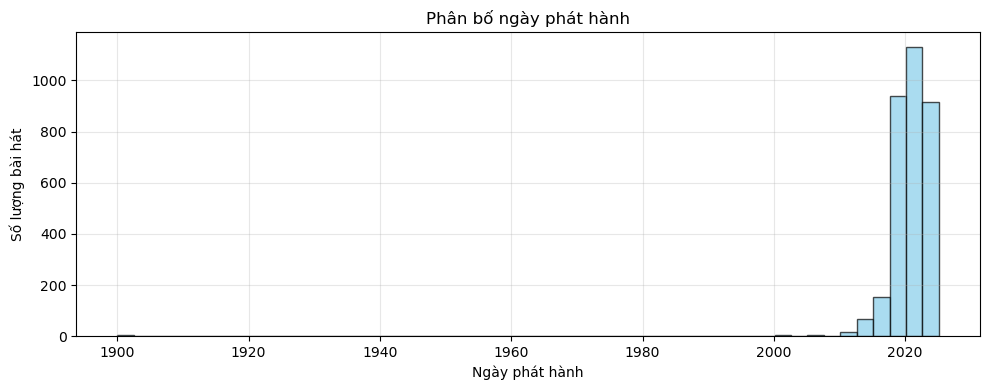

In [20]:
print("Ngày phát hành lâu nhất:", music_df['release_date'].min())
print("Ngày phát hành gần đây nhất:", music_df['release_date'].max())

plt.figure(figsize=(10, 4))
music_df['release_date'].hist(bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Phân bố ngày phát hành')
plt.xlabel('Ngày phát hành')
plt.ylabel('Số lượng bài hát')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('tracks_by_year_be.svg')
plt.show()

Như vậy qua biểu đồ trên, có thể thấy một điểm bất thường về thời gian phát hành của các bài hát trong dữ liệu: dữ liệu có bài hát phát hành từ năm 1900 đến tận 2025, trong đó có một số bài hát rất cũ (năm 1900-2000) chiếm tỉ lệ rất nhỏ, điều này có thể là do sai lệch dữ liệu hoặc do các bài hát này thực sự phát hành từ những năm đó. Để tìm hiểu rõ hơn, nhóm em thực hiện lấy ra những bài hát phát hành trước năm 2000 để xem xét.

In [21]:
y1900s_df = music_df[music_df['release_date'].dt.year < 2000]
print('Số lượng bài hát phát hành trước năm 2000:', y1900s_df.shape[0])
y1900s_df

Số lượng bài hát phát hành trước năm 2000: 13


,track_name,album_name,artist_name,genres,release_date,duration_ms,explicit,wks,t10,pk_rank,pk_streams,total_streams
560,All I Want for Christmas Is You,Merry Christmas,Mariah Carey,['christmas'],1994-10-28,241106.0,False,35,1,10,197932,2669032
781,Last Christmas,LAST CHRISTMAS,Wham!,['christmas'],1984-11-29,262960.0,False,26,0,13,142900,1583225
1165,Jingle Bell Rock,Jingle Bell Rock/Captain Santa Claus (And His ...,Bobby Helms,['christmas'],1957-12-02,130973.0,False,17,0,42,69914,678502
1189,Running Up That Hill (A Deal With God),Hounds Of Love,Kate Bush,"['art pop', 'baroque pop', 'art rock']",1985-09-16,298933.0,False,10,0,71,82502,647513
1293,Rockin' Around The Christmas Tree,Merry Christmas From Brenda Lee,Brenda Lee,['christmas'],1964-10-19,126266.0,False,13,0,66,65431,506283
1696,"Đây Là Rap Việt (feat. Binz, JustaTee, Rhymast...","Rap Việt, Vòng 1",RAP VIỆT,"['vietnamese hip hop', 'v-pop']",1900-01-01,180600.0,False,6,0,71,49468,248430
1996,Lemon Tree,Dish of the Day,Fools Garden,[],1995-01-01,191026.0,False,5,0,89,36801,154132
2001,It's the Most Wonderful Time of the Year,The Andy Williams Christmas Album,Andy Williams,['christmas'],1963-11-24,151933.0,False,7,0,72,46263,153227
2214,Let It Snow! Let It Snow! Let It Snow!,A Winter Romance,Dean Martin,"['christmas', 'adult standards', 'big band', '...",1959-01-01,117146.0,False,4,0,99,44575,113522
2701,Bohemian Rhapsody - Remastered 2011,A Night At The Opera (2011 Remaster),Queen,"['classic rock', 'rock', 'glam rock']",1975-11-21,354320.0,False,7,0,54,9953,53679


Như vậy có tổng cộng 13 bài hát có ngày phát hành trước năm 2000, có thể thấy đa số các bài hát này đều là những bài hát Âu Mỹ cũ rất nổi tiếng như "All I Want for Christmas Is You, Last Christmas, Jingle Bell Rock,...". Và sau khi thực hiện kiểm tra lại ngày phát hành của những bài hát, nhóm em phát hiện có **4 bài hát có ngày phát hành rất bất thường** khi đều được phát hành vào ngày **01/01/1900**, là các bài: "Đây Là Rap Việt, Anh Vẫn OK, Rằm Tháng 7, Phố Đêm", và sau khi tìm hiểu thì các lỗi này xuất phát từ Spotify (thông tin ngày ra mắt của các bài hát này trên Spotify không chính xác). Do đó, nhóm quyết định sẽ chỉnh sửa thủ công ngày phát hành của những bài hát này để đảm bảo tính chính xác.

In [22]:
wrong_dates_indices = [1696, 2718, 2819]
for i in wrong_dates_indices:
    music_df.at[i, 'release_date'] = pd.to_datetime('2020-10-08')
music_df.at[3168, "release_date"] = pd.to_datetime('1995-06-25')

Hơn nữa, sau khi xóa các dòng bị thiếu dữ liệu, để thuận tiện cho việc phân tích, nhóm sẽ chuyển đổi đơn vị của cột `duration_ms` từ **milliseconds (ms)** sang **phút (mins)**, giúp các số liệu trực quan, gần gũi và dễ diễn giải hơn.

In [23]:
music_df['duration_ms'] = (music_df['duration_ms'] / 60000).round(2)
music_df.rename(columns={'duration_ms': 'duration_min'}, inplace=True)

In [24]:
print(f'số lượng bài hát sau khi xử lý: {music_df.shape[0]}')

số lượng bài hát sau khi xử lý: 3247


## 4. Thống kê mô tả

Sau khi đã kiểm tra kiểu dữ liệu và xử lý một số dữ liệu bị thiếu, tiến hành thực hiện một số thống kê mô tả cơ bản của dữ liệu.

### 4.1. Đối với các cột dạng số
Đâu tiên, nhóm em sẽ xem xét các cột dạng số bao gồm các thông tin sau:
- Các chỉ số thống kê như trung bình, độ lệch chuẩn, min, max,..
- Phân phối của dữ liệu.

Đầu tiên, xem xét các chỉ số thống kê của các cột dữ liệu số.

In [25]:
def format_large_numbers(x):
    if x >= 1_000_000_000:
        b = x / 1_000_000_000
        if b.is_integer():
            return f"{int(b)}B"
        else:
            return f"{b:.3f}B"
    elif x >= 1_000_000:
        m = x / 1_000_000
        if m.is_integer():
            return f"{int(m)}M"
        else:
            return f"{m:.3f}M"
    elif x.is_integer():
        return f"{int(x)}"
    else:
        return f"{x:.3f}".rstrip('0').rstrip('.')

In [26]:
numeric_columns = music_df.select_dtypes(include=[np.number]).columns
numeric_description = music_df.describe(include=[np.number])
numeric_description = numeric_description.round(3)
numeric_description = numeric_description.map(format_large_numbers)
numeric_description

,duration_min,wks,t10,pk_rank,pk_streams,total_streams
count,3247,3247,3247,3247,3247,3247
mean,3.557,21.076,1.071,76.145,157311.125,2.302M
std,0.803,36.585,4.561,59.728,310689.741,6.964M
min,0.56,1,0,1,4795,13350
25%,3.06,2,0,21,28552.5,69846.5
50%,3.47,6,0,64,61727,250220
75%,3.97,21,0,125,172181,1.424M
max,10.22,358,84,200,7.520M,200.423M


Để hiểu rõ hơn về phân phối của các cột dữ liệu dạng số, nhóm em sẽ trực quan hóa bằng biểu đồ histogram, từ đó có được cái nhìn tổng quát hơn về dữ liệu.

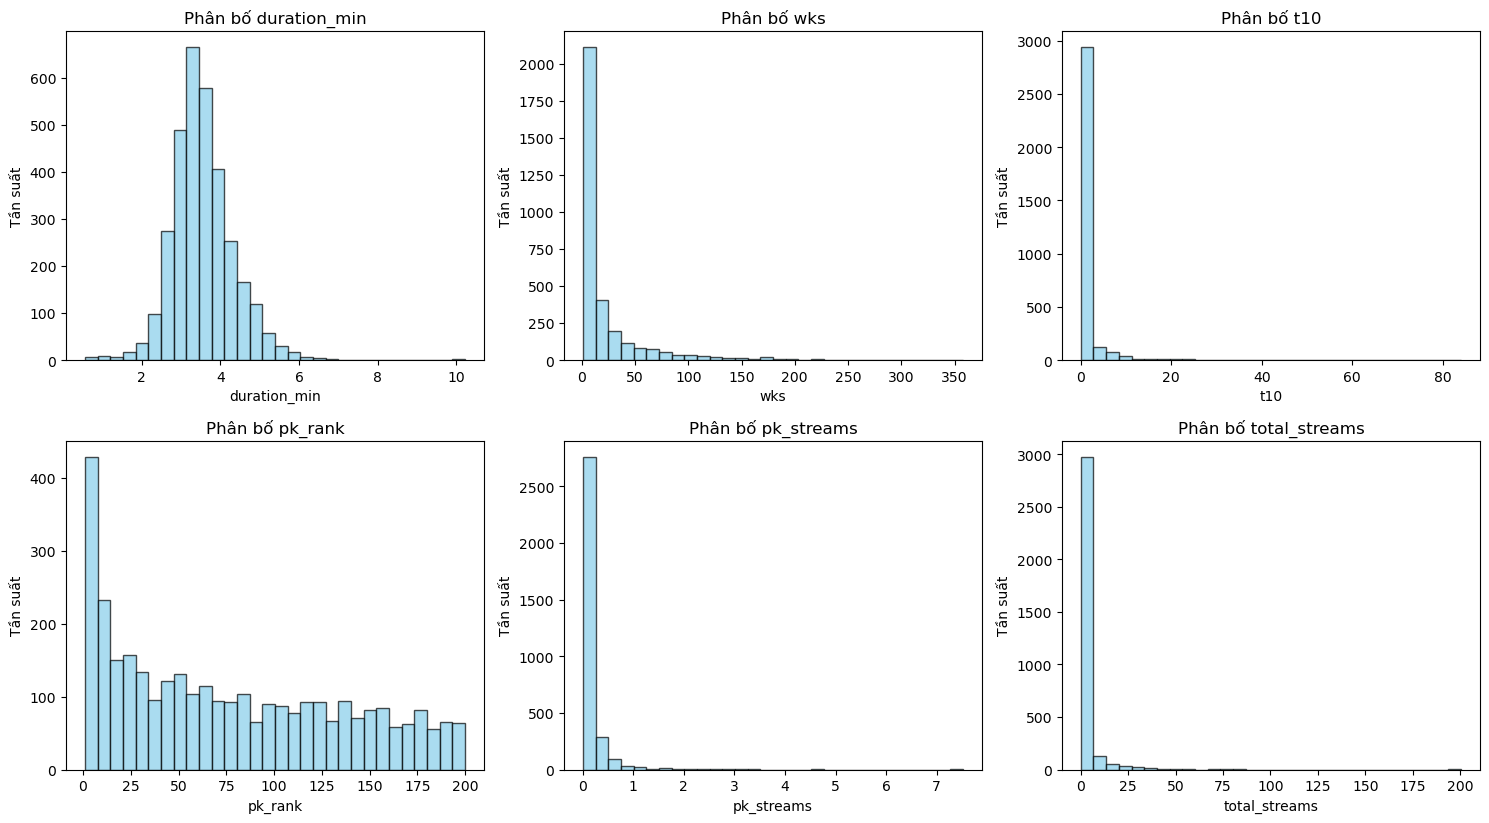

In [27]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
his_df = music_df.drop(['track_name','album_name','artist_name','genres','release_date', 'explicit'], axis=1)
his_df['pk_streams'] = his_df['pk_streams'] / 1e6
his_df['total_streams'] = his_df['total_streams'] / 1e6

for i, col in enumerate(numeric_columns):
    axes[i].hist(his_df[col], bins=30, color="skyblue", edgecolor="black", alpha=0.7)
    axes[i].set_title(f"Phân bố {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Tần suất")

# Ẩn các ô trống
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
# plt.savefig('histogram.svg')
plt.show()

Như vậy, thông qua bảng số liệu thống kê và biểu đồ histogram trên, có thể rút ra được những quan sát thống kê về bộ dữ liệu như sau:

- `duration_min`:  
  - Thời lượng trung bình của các bài hát là khoảng 3.56 phút.  
  - Thời lượng lớn nhất là khoảng 10.22 phút, có thể là một bài hát dài hoặc bản nhạc đặc biệt.  
  - 50% số bài hát có thời lượng từ 3.06 phút đến 3.97 phút, cho thấy hầu hết bài hát có độ dài phổ biến khoảng 3-4 phút.
  - Histogram cho thấy phân phối gần như chuẩn, tập trung quanh 3-4 phút với một số ngoại lệ có thời lượng dài hơn.

- `wks` (số tuần xuất hiện trên bảng xếp hạng):  
  - Trung bình một bài hát trụ lại trên bảng xếp hạng 21.07 tuần.  
  - Bài hát trụ lâu nhất có 358 tuần trên bảng xếp hạng, có thể là một bài hát kinh điển hoặc hit dài hạn.  
  - 50% số bài hát có từ 2 đến 21 tuần trên bảng xếp hạng, cho thấy nhiều bài hát có "tuổi thọ" không dài trên bảng xếp hạng. 
  - Histogram cho thấy phân phối lệch phải mạnh, đa số bài hát chỉ tồn tại ngắn trên BXH, số ít trụ được lâu, thể hiện phần nào xu hướng nghe nhạc sôi động ở thị trường âm nhạc Việt Nam, các bài hát cũ liên tục bị thay thế bởi các bài hát mới.

- `t10` (số tuần trong Top 10):  
  - Trung bình một bài hát chỉ có 1.071 tuần nằm trong Top 10.  
  - Bài hát có thành tích tốt nhất có 84 tuần trong Top 10, thể hiện mức độ thành công vượt trội.  
  - 75% số bài hát không vào được Top 10, chỉ có một số ít bài hát thành công đạt thứ hạng cao.  
  - Histogram thể hiện phân phối cực kỳ lệch phải, phần lớn bài hát không vào được top 10.

- `pk_rank` (thứ hạng cao nhất đạt được):  
  - Trung bình thứ hạng cao nhất mà các bài hát đạt được là 76.145.   
  - 50% số bài hát có thứ hạng cao nhất trong khoảng 21 - 125, tức là một số bài hát có thể chưa từng lọt vào top cao.  
  - Histogram cho thấy phân phối tương đối đều từ hạng 1 đến 200, với xu hướng tăng nhẹ ở các hạng thấp hơn.

- `pk_streams` (số lượt stream cao nhất trong một tuần):  
  - Trung bình số lượt stream cao nhất trong một tuần là 157311 lượt.  
  - Mức cao nhất đạt được là 7,520 triệu lượt stream trong một tuần, đây là một con số cực kỳ ấn tượng.  
  - 50% số bài hát có lượt stream cao nhất dưới 61727, cho thấy phần lớn các bài hát có lượt stream tương đối thấp.  
  - Histogram thể hiện phân phối lệch phải cực mạnh, số ít bài hát đạt được lượt stream rất cao.

- `total_streams` (tổng số lượt stream):  
  - Trung bình tổng lượt stream của một bài hát là 2,302 triệu lượt.  
  - Bài hát có tổng lượt stream cao nhất đạt 200,423 triệu lượt, đây có thể là một bản hit toàn cầu.  
  - 50% số bài hát có tổng lượt stream từ 0,69846 đến 1,424 triệu, cho thấy đa phần bài hát có độ phổ biến vừa phải, chỉ một số ít đạt con số cực cao.  
  - Histogram thể hiện phân phối lệch phải rất mạnh, tương tự như pk_streams, với một số ít bài hát chiếm phần lớn tổng lượt stream.

### 4.2. Đối với các cột dạng phân loại

Nhóm em sẽ phân các cột dạng phân loại thành các nhóm như sau:

- **Các cột có giá trị đơn:**  
  - `track_name`: Tên bài hát.  
  - `album_name`: Tên album chứa bài hát.  
  - `artist_name`: Tên nghệ sĩ hoặc ban nhạc.  
  - `release_date`: Ngày phát hành bài hát.  
  - `explicit`: Chỉ định bài hát có nội dung nhạy cảm hay không (True/False).  

- **Các cột có nhiều giá trị khác nhau:**  
  - `genres`: Thể loại âm nhạc của bài hát. Một bài hát có thể thuộc nhiều thể loại khác nhau.  


In [28]:
single_value_columns = ['track_name', 'artist_name', 'album_name', 'release_date']
multi_value_columns = ['genres']

**Đầu tiên, xem xét các cột có giá trị đơn**

Cột `explicit` chỉ chứa 2 giá trị `True` và `False`nên nhóm em sẽ biến đổi cột này thành dạng bool.

In [29]:
music_df['explicit'] = music_df['explicit'].astype(bool)

Tiếp theo, xem các thông tin thống kê cơ bản của các cột này, lưu ý, cột `release_date` sẽ được xem xét riêng vì nó là cột dữ liệu kiểu thời gian.

In [30]:
music_df[single_value_columns].describe(exclude=['datetime']).T

,count,unique,top,freq
track_name,3247,3122,Life Goes On,4
artist_name,3247,808,BTS,141
album_name,3247,2074,Lover,18


Sau khi xem qua các chỉ số thống kê cơ bản ở trên, có các nhận xét sau:

- **Cột `track_name`** có 3122 giá trị duy nhất trên tổng số 3247 bài nhạc. Điều này có nghĩa là có một số bài hát trùng tên nhau. Bài hát xuất hiện nhiều nhất là *"Life Goes On"*, với tần suất 4 lần.

- **Cột `artist_name`** có 808 nghệ sĩ khác nhau. Nghệ sĩ có số lượng bài hát nhiều nhất là **BTS**, với tổng cộng 141 bài. Từ đó có thể thấy rằng nghệ sĩ/nhóm nghệ sĩ này được yêu thích nhiều nhất tại thị trường Việt Nam, cho thấy mức độ phổ biến của BTS trong cộng đồng người nghe nhạc tại Việt Nam.

- **Cột `album_name`** có 2074 giá trị duy nhất trên tổng số 3247 bài nhạc, cho thấy mỗi album thường có ít bài hát trong dataset. Album phổ biến nhất là *"Lover"*, với 18 bài hát.

Bây giờ, nhóm em sẽ xem xét cột `release_date`:

In [31]:
music_df['release_date'].describe()

count                             3247
mean     2020-10-09 15:25:33.353865216
min                1957-12-02 00:00:00
25%                2019-04-05 00:00:00
50%                2020-12-16 00:00:00
75%                2022-10-31 00:00:00
max                2025-02-24 00:00:00
Name: release_date, dtype: object

In [32]:
music_df['release_date'].astype(str).describe()

count           3247
unique          1361
top       2018-12-14
freq              25
Name: release_date, dtype: object

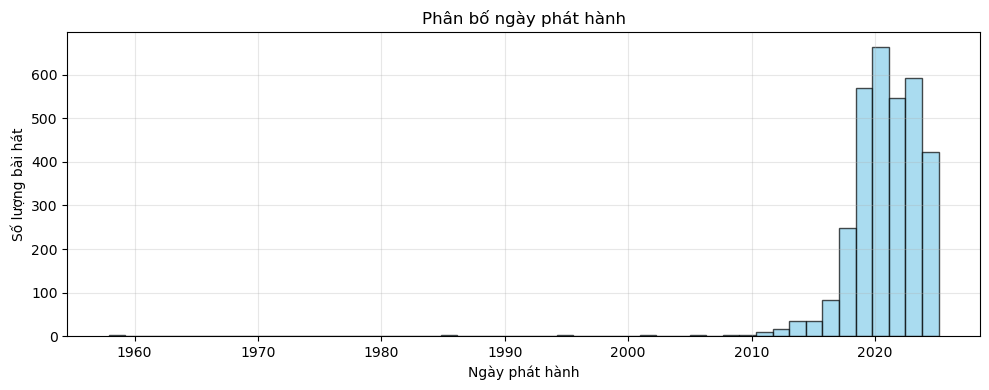

In [33]:
plt.figure(figsize=(10, 4))
music_df['release_date'].hist(bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Phân bố ngày phát hành')
plt.xlabel('Ngày phát hành')
plt.ylabel('Số lượng bài hát')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('tracks_by_year_af.svg')
plt.show()

Như vậy, nhóm em rút ra được một số thông tin hữu ích về ngày phát hành của các bài hát như sau:

- Bài hát đầu tiên được phát hành trong tập dữ liệu vào năm **1957**, và bài hát được hành gần nhất mà dữ liệu ghi nhận là vào năm **2025**.
- Ngày có nhiều bài hát được ra mắt nhất là **14/12/2018** với **25** bài hát.
- Có thể thấy một số bài hát đã được phát hành từ rất lâu trước đây. Đây có thể là những ca khúc bất hủ với chủ đề quen thuộc, thường xuyên được nghe lại vào những dịp đặc biệt. Tuy nhiên, hầu hết các bài hát trong tập dữ liệu đều có ngày phát hành từ năm **2019** tới **2025**, thể hiện **bộ dữ liệu mà nhóm thu thập được đảm bảo được tính cập nhật và phản ánh xu hướng âm nhạc trong những năm gần đây, giúp cho việc phân tích có ý nghĩa hơn khi tập trung vào các bài hát phổ biến và được quan tâm trên nền tảng Spotify ở thị trường Việt Nam trong giai đoạn hiện tại.**

**Tiếp theo, nhóm sẽ xem xét và xử lý các cột có nhiều giá trị khác nhau.**

In [34]:
music_df[multi_value_columns].describe().T

,count,unique,top,freq
genres,3247,196,[],757


Cột `genres` chứa tới **757** giá trị **[]**, điều này cho thấy có rất nhiều bài nhạc không có thông tin về thể loại mà nó thuộc về. 
Do đó, nhóm em sẽ xử lí bằng cách điền vào giá trị "Unknown" cho các giá trị thiếu trong cột `genres` để tránh mất mát dữ liệu mà vẫn giữ được ý nghĩa phân tích.

In [35]:
def extract_genres_list(value):
    if pd.isna(value):
        return np.nan
    try:
        genres_list = ast.literal_eval(value)
        if not isinstance(genres_list, list):
            return np.nan
        if genres_list == []:
            return np.nan
        return genres_list
    except (ValueError, SyntaxError, TypeError):
        return np.nan
    
music_df['genres'] = music_df['genres'].apply(extract_genres_list)
music_df['genres'] = music_df['genres'].apply(lambda x: ['Unknown'] if x is np.nan or len(x) == 0 else x)

Ngoài ra, có thể thấy rằng các giá trị của cột `Genres` được lưu dưới dạng danh sách, để nắm được thông tin cơ bản về phân phối của dữ liệu, nhóm em sẽ phân tách các giá trị trong cột này ra bằng cách "explode" chúng thành các dòng riêng biệt.

In [36]:
genres_explode_df = music_df.explode('genres')
print(f"Bộ dữ liệu có {genres_explode_df['genres'].nunique()} thể loại khác nhau.")
print(f"Top 10 thể loại phổ biến nhất:")
print(genres_explode_df['genres'].value_counts().head(10))

Bộ dữ liệu có 121 thể loại khác nhau.
Top 10 thể loại phổ biến nhất:
genres
v-pop                 1348
vietnam indie          902
vietnamese hip hop     876
Unknown                757
k-pop                  649
vietnamese lo-fi       640
vinahouse              510
pop                    176
soft pop                94
k-rap                   91
Name: count, dtype: int64


Như vậy, từ kết quả phân tích cột `genres`, có thể thấy rằng:

- Top 5 thể loại âm nhạc phổ biến nhất tại Việt Nam là:
    1. **V-pop**: 1348 bài hát
    2. **Vietnam indie**: 902 bài hát  
    3. **Vietnamese hip hop**: 876 bài hát
    4. **K-pop**: 649 bài hát
    5. **Vietnamse lo-fi**: 640 bài hát

- V-pop chiếm ưu thế áp đảo, cho thấy nhạc Việt vẫn là dòng nhạc chủ đạo được mọi người ưa chuộng, bên cạnh đó K-pop cũng có vị trí quan trọng trong thị trường âm nhạc Việt Nam, cho thấy sự ảnh hưởng của Hàn Quốc trong ngành giải trí.
- Thị trường âm nhạc Việt Nam phản ánh sự đa dạng về thể loại, với sự kết hợp giữa nhạc trong nước và quốc tế.

In [37]:
music_df.shape

(3247, 12)

### Tổng kết lại, sau khi khám phá và thực hiện các thống kê nhóm em có các nhận xét sau:

- Sau khi xử lý toàn bộ dữ liệu, nhóm em thu được bộ dữ liệu có ý nghĩa phân tích cuối cùng với 3247 bài hát (track) và 12 trường thông tin có ý nghĩa.
- Toàn bộ bộ dữ liệu có 808 nghệ sĩ khác nhau, với nghệ sĩ có số lượng bài hát nhiều nhất là **BTS**, với tổng cộng 141 bài. Từ đó có thể thấy rằng nghệ sĩ/nhóm nghệ sĩ này được yêu thích nhiều nhất tại thị trường Việt Nam, cho thấy mức độ phổ biến của BTS trong cộng đồng người nghe nhạc tại Việt Nam.
- Hầu hết các bài hát trong tập dữ liệu đều có ngày phát hành từ năm **2019** tới **2025**, thể hiện được bộ dữ liệu thu thập được đảm bảo được tính cập nhật từ đó phản ánh xu hướng âm nhạc trong những năm gần đây, giúp cho việc phân tích có ý nghĩa hơn khi tập trung vào các bài hát phổ biến và được quan tâm trên nền tảng Spotify ở thị trường Việt Nam trong giai đoạn hiện tại.
- Các thể loại `Genres` tại thị trường Việt Nam rất đa dạng, với 121 thể loại khác nhau, trong đó V-pop chiếm ưu thế áp đảo, cho thấy nhạc Việt vẫn là dòng nhạc chủ đạo được mọi người Việt Nam ưa chuộng, bên cạnh đó K-pop cũng có vị trí quan trọng trong thị trường âm nhạc Việt Nam, cho thấy sự ảnh hưởng của Hàn Quốc trong ngành giải trí.

Tóm lại, sau khi được xử lý và khám phá, bộ dữ liệu đã cho cái nhìn cơ bản tổng quan về thị trường âm nhạc Việt Nam. 

Cuối cùng, xuất dữ liệu ra file mới sau khi đã được xử lí để cho việc phân tích sâu hơn về thị trường âm nhạc Việt Nam.

In [38]:
music_df.to_csv('Data/cleaned_data/clean_data.csv', index=False, sep='\t', encoding='utf-8-sig')

<div style="text-align:left; border-radius:15px; padding:15px; margin:0; font-size:200%; font-family:Arial, sans-serif; background-color:#404040; color:#1ED760; box-shadow:0 4px 8px rgba(0, 0, 0, 0.3);">
  <b>Phân tích và Trực quan hóa dữ liệu</b>
</div>

Đọc dữ liệu đã được xử lí vào DataFrame `df`

In [39]:
df = pd.read_csv('Data/cleaned_data/clean_data.csv', sep='\t')
df['release_date'] = pd.to_datetime(df['release_date'])

## Câu hỏi 01: Những nghệ sĩ nào đang thống trị Spotify Việt Nam những năm gần đây, và điều đó phản ánh điều gì về thị hiếu âm nhạc của khán giả cũng như những thay đổi trong thị trường âm nhạc Việt Nam?

Trong những năm gần đây, thị trường âm nhạc Việt Nam trên Spotify chứng kiến sự cạnh tranh gay gắt và sôi động với hàng trăm nghìn bài hát mới với hàng chục triệu lượt stream. Nhưng những cái tên đứng đầu là ai? Họ là những gương mặt quen thuộc hay những ngôi sao bất ngờ với những người hâm mộ âm nhạc Việt Nam?  

Không chỉ dừng lại đó, một câu hỏi quan trọng hơn nảy ra: **Những nghệ sĩ này đến từ đâu?** Liệu khán giả Việt Nam ưu ái những giai điệu quen thuộc trong nước, hay bị cuốn theo những bản hit toàn cầu? Từ đó ta sẽ có thể có cái nhìn tổng quát hơn về sở thích nghe nhạc của người dùng Việt Nam.  

Biểu đồ dưới đây sẽ giúp chúng ta tìm ra câu trả lời:

### Những nghệ sĩ nào đang dẫn đầu, và họ đến từ đâu?
Spotify đã trở thành cầu nối giữa âm nhạc Việt Nam và quốc tế, và trong dòng chảy âm nhạc đó, nghệ sĩ trong nước hay quốc tế đang chiếm ưu thế? Biểu đồ cột dưới đây sẽ cho chúng ta thấy top 10 nghệ sĩ có tổng lượt stream cao nhất cùng với sự phân loại nghệ sĩ trong nước - quốc tế. Từ đó ta sẽ có cái nhìn tổng quát hơn về thị trường âm nhạc sôi động ở việt Nam.

Đầu tiên, tạo thêm một cột mới để phân biệt giữa những nghệ sĩ trong nước và nước ngoài dựa trên `genres`.

In [40]:
def classify_origin(genres):
    genres = eval(genres) if isinstance(genres, str) and genres.startswith('[') else genres
    vietnamese_genres = ['v-pop', 'vietnamese hip hop', 'vietnam indie', 'vietnamese lo-fi', 'vinahouse']
    if any(genre in vietnamese_genres for genre in genres):
        return 'VN'
    return 'International'

df['origin'] = df['genres'].apply(classify_origin)

Tính tổng lượt stream theo nghệ sĩ và xuất ra top 10 nghệ sĩ có lượt stream cao nhất, từ đó vẽ biểu đồ trực quan hóa để thấy rõ hơn.

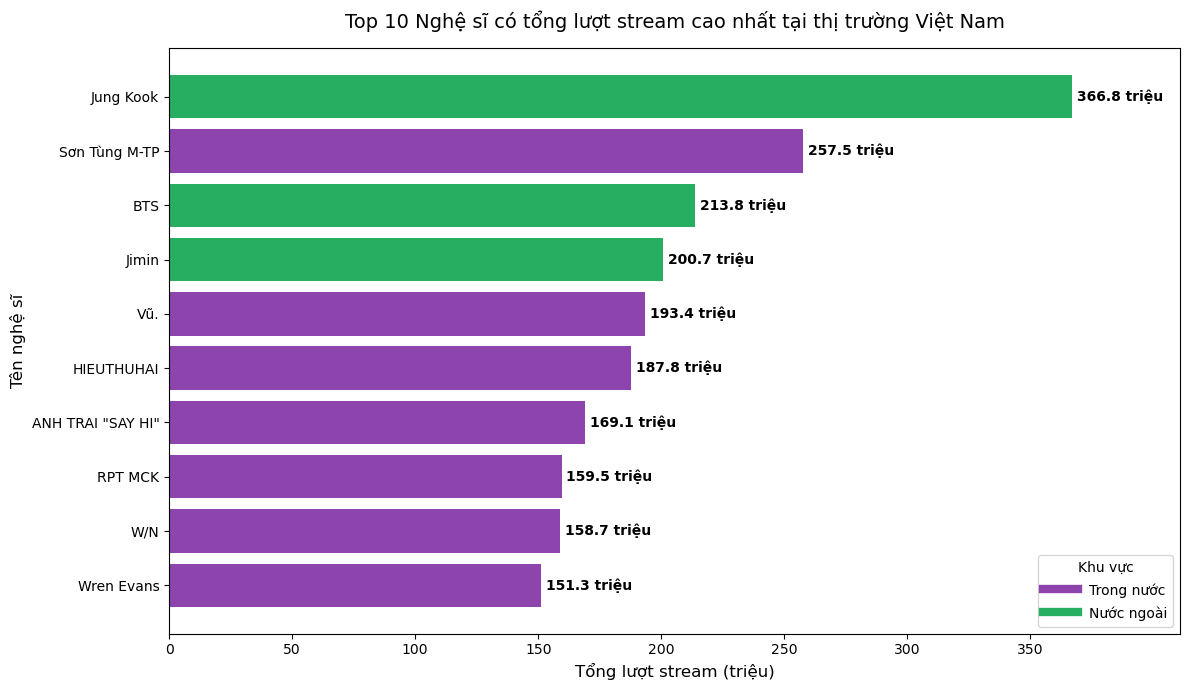

In [41]:
# Tính tổng lượt stream theo nghệ sĩ và lấy top 10
top_10_artists = df.groupby(['artist_name', 'origin'])['total_streams'].sum().nlargest(10).reset_index()

color_map = {'VN': '#8E44AD', 'International': '#27AE60'}
colors = top_10_artists['origin'].map(color_map)

plt.figure(figsize=(12, 7))
bars = plt.barh(top_10_artists['artist_name'], top_10_artists['total_streams'] / 1e6, color=colors)
plt.title('Top 10 Nghệ sĩ có tổng lượt stream cao nhất tại thị trường Việt Nam', fontsize=14, pad=15)
plt.xlabel('Tổng lượt stream (triệu)', fontsize=12)
plt.ylabel('Tên nghệ sĩ', fontsize=12)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2, f'{width:.1f} triệu', 
             ha='left', va='center', fontsize=10, color='black', weight='bold')
plt.gca().invert_yaxis()
legend_labels = [plt.Line2D([0], [0], color=color_map['VN'], lw=6, label='Trong nước'),
                 plt.Line2D([0], [0], color=color_map['International'], lw=6, label='Nước ngoài')]
plt.legend(handles=legend_labels, title="Khu vực", loc='lower right',fontsize=10,
           markerscale=1.5, handleheight=1.2, handlelength=2.5, labelspacing=0.6 )

plt.xticks([x * 50 for x in range(0, int(max(top_10_artists['total_streams']) / 1e6 / 50) + 1)], fontsize=10)
plt.margins(x=0.12)
plt.tight_layout()
# plt.savefig('q1_1.svg')
plt.show()

Từ biểu đồ trên, ta có thể thấy rằng:
- JungKook dẫn đầu với 366.8 triệu lượt stream, vượt Sơn Tùng M-TP (257.5 triệu), cho thấy sức hút mạnh mẽ của K-pop đối với thị trường âm nhạc Việt Nam, trong khi Sơn Tùng – biểu tượng của sự thành công nhạc Việt với phong cách độc đáo và sự kiên trì, vẫn giữ vững vị trí thứ hai.
- Bên cạnh đó, chúng ta cũng thấy được sự nổi lên của các nghệ sĩ trẻ như HIEUTHUHAI (187.8 triệu), RPT MCK (159.5 triệu), W/N (158.7 triệu), và Wren Evans (151.3 triệu) đánh dấu một thế hệ mới đầy tiềm năng, phản ánh thị hiếu của khán giả Gen Z hướng tới âm nhạc năng động và gần gũi, đồng thời cho thấy sự chuyển giao thế hệ trong ngành âm nhạc nội địa.
- Đặc biệt vòa năm 2024, chương trình "Anh Trai Say Hi" đã tạo ra một hiện tượng văn hóa khi nâng tầm các nghệ sĩ trẻ với hàng chục bài hit, khẳng định tiềm năng phát triển công nghiệp giải trí Việt Nam.
- Như vậy, sự kết hợp giữa những nghệ sĩ quốc tế (JungKook, BTS, Jimin) và nội địa (Sơn Tùng, Vũ,..) trong top 10, cùng sự phát triển của nghệ sĩ trẻ (Wren Evans, W/N,..), cho thấy thị trường âm nhạc Việt Nam sôi động và đa chiều, bên cạnh đó cũng đặt ra nhiều thách thức cho các nghệ sĩ trong việc duy trì sức hút, đòi hỏi sự đổi mới liên tục để tránh bị lu mờ.

### Hành trình thu hút khán giả Việt Nam của những nghệ sĩ này có điều gì đặc biệt? Và điều đó có phản ánh gì về thị hiếu âm nhạc của khán giả cũng như những thay đổi trong thị trường âm nhạc Việt Nam không?

Làm thế nào các nghệ sĩ này đã định hình xu hướng âm nhạc qua các năm, từ sự bứt phá mạnh mẽ của K-pop, sự bền vững của nghệ sĩ nội địa, đến sự nổi lên của hip-hop trẻ? Biểu đồ nhiệt dưới đây sẽ đưa chúng ta qua hành trình của top 10 nghệ sĩ này những năm gần đây cho đến hiện tại, vẽ nên bức tranh về cách họ chinh phục khán giả Việt Nam. Từ sự ổn định của những tên tuổi lớn đến những đợt bùng nổ bất ngờ của những gương mặt trẻ, xu hướng này sẽ tiết lộ gu âm nhạc của người hâm mộ âm nhạc Việt Nam: bền vững hay chạy theo trào lưu?

Lọc top 10 nghệ sĩ có tổng lượt stream cao nhất thành data frame mới

In [42]:
top_10_artists_df = df[df['artist_name'].isin(top_10_artists['artist_name'])]

Vẽ biểu đồ trực quan hóa

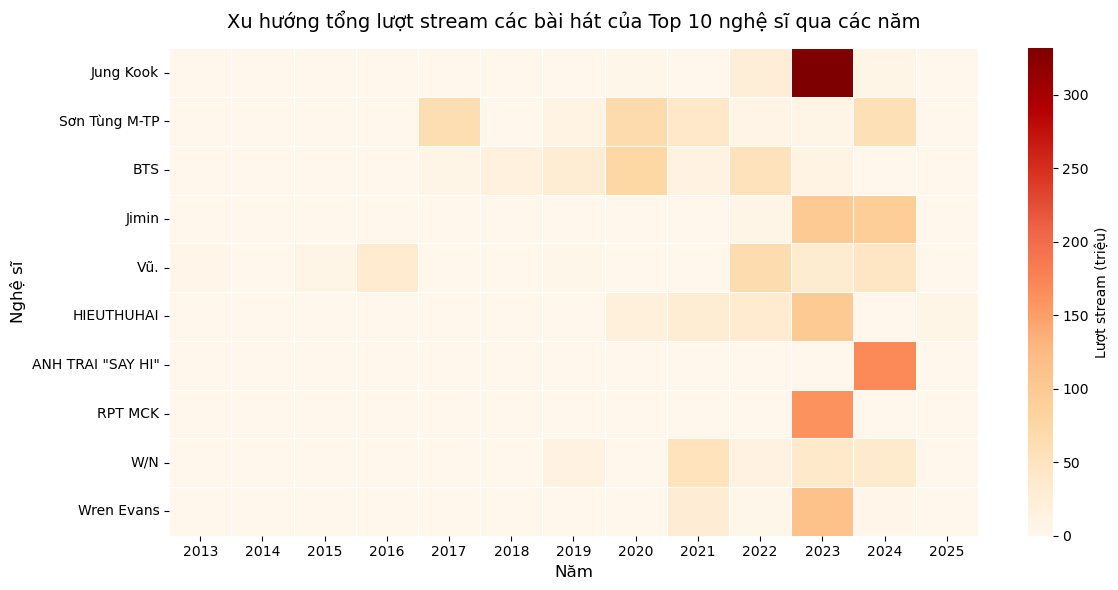

In [43]:
top_10_artists_df['year'] = top_10_artists_df['release_date'].dt.year
trend_df = top_10_artists_df.groupby(['artist_name', 'year'])['total_streams'].sum().unstack().fillna(0)
sorted_artists = trend_df.sum(axis=1).sort_values(ascending=False).index
trend_df = trend_df.loc[sorted_artists]

# Tạo heatmap dữ liệu lượt stream theo năm
plt.figure(figsize=(12, 6))
sns.heatmap(trend_df / 1e6, cmap='OrRd', annot=False, fmt='.1f', linewidths=0.5, cbar_kws={'label': 'Lượt stream (triệu)'})
plt.title('Xu hướng tổng lượt stream các bài hát của Top 10 nghệ sĩ qua các năm', fontsize=14, pad=15)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Nghệ sĩ', fontsize=12)
plt.tight_layout()
# plt.savefig('q1_2.svg')
plt.show()

Từ biểu đồ trên, ta có cái nhìn rằng:
- JungKook là cái tên có ô màu đậm nhất, đặc biệt JungKook đạt đỉnh 300 triệu vào khoảng 2023-2024, bứt phá và vượt xa các nghệ sĩ khác, phản ánh sức hút mạnh mẽ của K-pop nói chung và riêng nghệ sĩ này nói riêng với thị trường âm nhạc Việt Nam.
- Sơn Tùng M-TP và Vũ. duy trì các ô màu từ 100-200 triệu thông qua những cú hit ở từng thời điểm khác nhau qua nhiều năm (2016-2024), chứng minh sự kiên trì phát hành, tài năng và sức ảnh hưởng bền vững của hai nghệ sĩ này đối với khán giả Việt.
- Đặc biệt từ năm 2020, với sự tăng trưởng nhiều lượt stream đối với các nghệ sĩ trẻ như HIEUTHUHAI, RPT MCK, Wren Evans,..thể hiện sự nổi lên của hip-hop trẻ, kết hợp giữa sự đổi mới của thị trường âm nhạc sôi động và sức mạnh từ cộng đồng fan.
- Các năm 2013-2016 hầu như không có dữ liệu đáng kể, vì do Spotify mới thâm nhập thị trường Việt Nam chính thức từ năm 2018, qua đó cũng cho ta thấy sự phát triển nhanh chóng và ngày càng sôi động của thị trường âm nhạc trực tuyến tại Việt Nam nói chung và ở Spotify nói riêng.
- Nhìn chung, thị trường âm nhạc Việt Nam đang ngày càng phát triển mạnh mẽ, với sự kết hợp giữa các nghệ sĩ lâu năm có lượng fan trung thành và thế hệ nghệ sĩ trẻ đầy tiềm năng. K-pop tiếp tục giữ vị thế là nhạc nước ngoài hàng đầu, trong khi hip-hop nội địa đang dần khẳng định sức ảnh hưởng với khán giả Việt qua những chương trình nổi bật như ANH TRAI "SAY HI".

## Câu hỏi 02: Sự khác biệt giữa nghệ sĩ trong nước và nước ngoài trong việc thu hút lượt stream trên Spotify Việt Nam phản ánh điều gì về thị hiếu âm nhạc và chiến lược phát hành?

Spotify đã mở ra cơ hội để khán giả Việt Nam tiếp cận cả âm nhạc nội địa và các bản hit quốc tế. Và tại thị trường âm nhạc Việt Nam đầy sôi động, liệu các bài hát trong nước hay quốc tế đang thực sự chiếm được trái tim của khán giả trẻ Việt Nam? Sự đa dạng về số lượng của âm nhạc nội địa có đủ sức cạnh tranh với sức hút mãnh liệt từ các ca khúc nước ngoài? Để trả lời câu hỏi này, nhóm sẽ sử dụng biểu đồ radar chart để so sánh tổng thể các chỉ số quan trọng như số lượng bài hát, tổng lượt stream, và khả năng lan tỏa trung bình (số lượt stream trung bình) của mỗi ca khúc, từ đó làm sáng tỏ xu hướng thị trường âm nhạc và sở thích của khán giả Việt Nam hiện nay.

Đầu tiên, cần tính toán 3 chỉ số so sánh giữa thị trường âm nhạc trong nước và quốc tế: tổng lượt stream, số lượng bài hát và số lượng lượt stream trung bình mỗi bài hát.

In [44]:
origin_streams = df.groupby('origin')['total_streams'].sum()
song_counts = df.groupby('origin').size()
avg_streams_per_song = (origin_streams / song_counts).round(0)

Vẽ radar chart để trực quan hóa các chỉ số một cách rõ ràng và dễ so sánh nhất

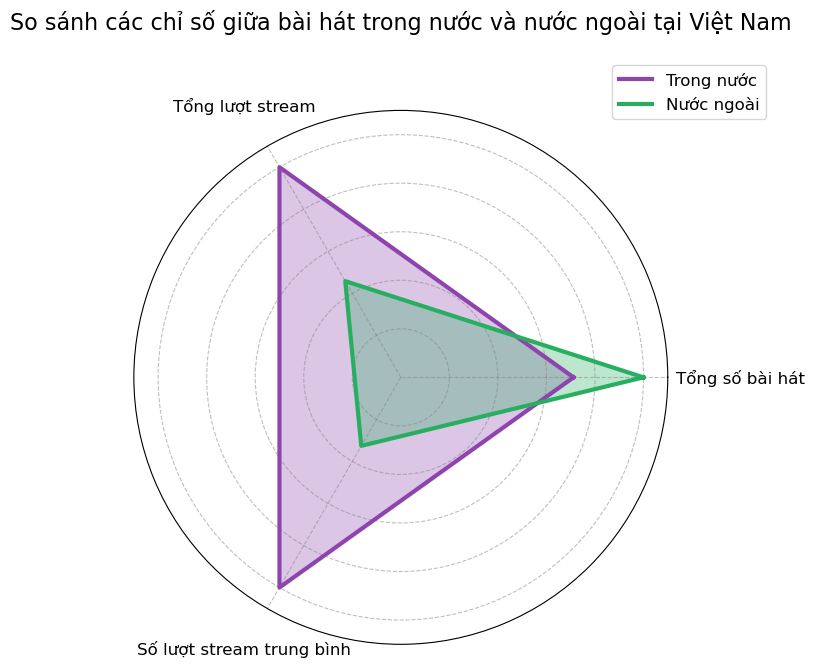

In [45]:
categories = ['Tổng số bài hát', 'Tổng lượt stream', 'Số lượt stream trung bình']
n_categories = len(categories)

# Giá trị thô cho hai nhóm
values_vn_raw = [
    song_counts['VN'],                    
    origin_streams['VN'] / 1e6,           
    avg_streams_per_song['VN'] / 1e6      
]
values_intl_raw = [
    song_counts['International'],        
    origin_streams['International'] / 1e6, 
    avg_streams_per_song['International'] / 1e6 
]

# Chuẩn hóa dữ liệu để vẽ radar chart
max_values = [
    max(values_vn_raw[0], values_intl_raw[0]),  
    max(values_vn_raw[1], values_intl_raw[1]),  
    max(values_vn_raw[2], values_intl_raw[2])   
]  
values_vn = [v / max_val for v, max_val in zip(values_vn_raw, max_values)]
values_intl = [v / max_val for v, max_val in zip(values_intl_raw, max_values)]
values_vn += values_vn[:1]
values_intl += values_intl[:1]
angles = [n / float(n_categories) * 2 * 3.14159 for n in range(n_categories)]
angles += angles[:1] 

# Khởi tạo radar chart
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='black', size=12)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], [])
plt.ylim(0, 1.1)

ax.plot(angles, values_vn, linewidth=3, linestyle='solid', label='Trong nước', color='#8E44AD')
ax.fill(angles, values_vn, alpha=0.3, color='#8E44AD')
ax.plot(angles, values_intl, linewidth=3, linestyle='solid', label='Nước ngoài', color='#27AE60')
ax.fill(angles, values_intl, alpha=0.3, color='#27AE60')


for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
    if label.get_text() == 'Tổng số bài hát':
        label.set_y(label.get_position()[1] - 0.2)
    else: 
        label.set_y(label.get_position()[1] - 0.1)

ax.grid(True, color='grey', linestyle='--', alpha=0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=12)
plt.title('So sánh các chỉ số giữa bài hát trong nước và nước ngoài tại Việt Nam', 
          size=16, color='black', y=1.1, pad=20)
plt.tight_layout()
# plt.savefig('q2.svg')
plt.show()

- Biểu đồ cho thấy khu vực trong nước có lợi thế về số lượng bài hát, nhưng nước ngoài lại dẫn đầu về tổng lượt stream và số lượt stream trung bình trên từng bài hát, điều này phản phản ánh sức hút mạnh mẽ của các bài hát quốc tế, có thể đến từ các hit K-pop nổi tiếng hoặc các bài hát Âu Mỹ đình đám đối với khán giả Việt Nam, cho thấy một thị hiếu mở cửa và chịu ảnh hưởng mạnh từ xu hướng quốc tế của thị trường âm nhạc Việt Nam, đặc biệt là đối với thế hệ trẻ.
-  Bên cạnh đó còn cho thấy các bài quốc tế ở thị trường âm nhạc Việt Nam tuy có số lượng khiêm tốn hơn, nhưng lại có khả năng lan tỏa sâu rộng. Thể hiện rằng khán giả Việt Nam có xu hướng tập trung vào những bản hit quốc tế có chất lượng cao và được quảng bá mạnh, trong khi âm nhạc nội địa, dù đa dạng, có thể chưa đạt được sự bùng nổ tương tự do thiếu sự đầu tư chuyên nghiệp hoặc chiến lược tiếp thị.

## Câu hỏi 3: Liệu thể loại nhạc phổ biến nhất có trùng với thể loại mà các nghệ sĩ hàng đầu sử dụng?

Thị trường âm nhạc trên Spotify Việt Nam không ngừng thay đổi với nhiều dòng nhạc khác nhau xuất hiện trên bảng xếp hạng. Nhưng liệu những thể loại có nhiều bài hát nhất trên nền tảng có phải cũng là những thể loại được các nghệ sĩ nổi tiếng theo đuổi?

Việc phân tích này sẽ giúp ta hiểu rõ hơn về mối quan hệ giữa sự phổ biến của thể loại và chiến lược âm nhạc của các nghệ sĩ thành công nhất. Nếu có sự trùng khớp, điều đó có thể cho thấy rằng thị hiếu của khán giả đang định hình hướng đi của nghệ sĩ. Ngược lại, nếu có sự khác biệt đáng kể, có thể các nghệ sĩ nổi tiếng đang có sức ảnh hưởng mạnh mẽ và dẫn dắt xu hướng nghe nhạc thay vì chạy theo thị hiếu.

Hai biểu đồ dưới đây sẽ giúp chúng ta trả lời câu hỏi này:

### Top 10 thể loại nhạc phổ biến nhất
Thị hiếu âm nhạc luôn thay đổi theo thời gian, nhưng liệu có một số thể loại luôn chiếm ưu thế trên bảng xếp hạng Spotify Việt Nam? Những dòng nhạc nào đang thống trị và trở thành xu hướng chủ đạo?

Biểu đồ dưới đây thể hiện 10 thể loại nhạc phổ biến nhất, dựa trên tổng số bài hát thuộc từng thể loại có mặt trên bảng xếp hạng. Qua đó, chúng ta có thể thấy được sự phân bố của các dòng nhạc và hiểu rõ hơn về gu thưởng thức âm nhạc của khán giả Việt Nam.

Đầu tiên ta sẽ xử lý phần genres để mỗi dòng chỉ có 1 genre thuận tiện cho việc đếm số bài hát

In [46]:
fixed_df = df.copy()
fixed_df['genres'] = (
    df['genres']
    .str.replace(r"[\[\]']", "", regex=True)  # Xóa dấu ngoặc vuông và dấu nháy đơn
    .str.split(', ')  # Chuyển thành danh sách các thể loại
)

# Loại bỏ các dòng chứa "unknown genre"
df_exploded = fixed_df.explode('genres')  # Tách mỗi thể loại thành một dòng riêng biệt
df_exploded = df_exploded[df_exploded['genres'].str.lower() != "unknown"]  # Loại bỏ dòng không có thể loại

Sau đó lấy ra top 10 và trực quan với biểu đồ bong bóng

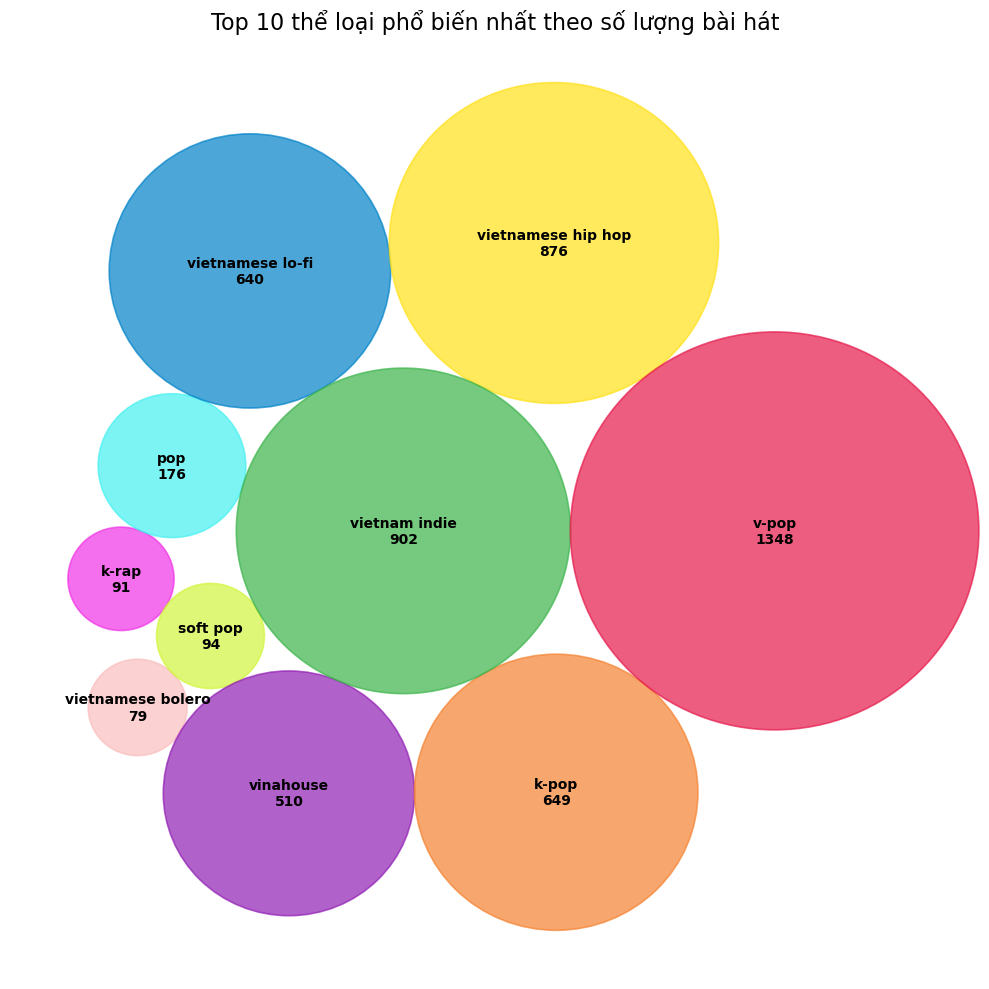

In [47]:
# Dữ liệu thể loại
genres_count = df_exploded['genres'].value_counts().head(10)
labels = genres_count.index.tolist()
values = genres_count.values.tolist()

# Bảng màu tương ứng với từng thể loại (định nghĩa thủ công dựa trên bubble chart)
genre_colors = {
    "v-pop": "#E6194B",
    "vietnam indie": "#3CB44B",
    "vietnamese hip hop": "#FFE119",
    "vietnamese lo-fi": "#0082C8",
    "k-pop": "#F58231",
    "vinahouse": "#911EB4",
    "pop": "#46F0F0",
    "k-rap": "#F032E6",
    "soft pop": "#D2F53C",
    "vietnamese bolero": "#FABEBE"
}

# Tạo bubble chart
circles = circlify.circlify(values, show_enclosure=False)
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(-1.0, 1.0)
ax.set_ylim(-1.0, 1.0)
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')

# Vẽ các hình tròn với màu sắc tương ứng
for i, circle in enumerate(circles):
    x, y, r = circle
    label = labels[9 - i]
    value = values[9 - i]
    color = genre_colors[label]  # Lấy màu theo thể loại

    ax.add_patch(plt.Circle((x, y), r, color=color, alpha=0.7, edgecolor='black', linewidth=1.2))
    ax.text(x, y, f"{label}\n{value}", ha='center', va='center', fontsize=10, weight='bold', color='black')

plt.title("Top 10 thể loại phổ biến nhất theo số lượng bài hát", fontsize=16, pad=2)
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
# plt.savefig("q3_1.svg", format="svg")
plt.tight_layout()
plt.show()

Từ biểu đồ trên ta thấy:
- V-Pop dẫn đầu với số lượng bài hát áp đảo so với các thể loại khác, cho thấy đây vẫn là dòng nhạc chủ đạo trong thị trường âm nhạc Việt Nam.
- Vietnam Indie và Vietnamese Hip-hop lần lượt giữ vị trí thứ hai và thứ ba, cho thấy xu hướng khán giả đang dần quan tâm hơn đến những dòng nhạc không thuộc thị trường mainstream. Đây có thể là dấu hiệu của sự thay đổi trong gu nghe nhạc, khi nhiều người tìm đến những bản nhạc có màu sắc riêng biệt và ít bị thương mại hóa.

- K-Pop xếp thứ tư, chứng minh sức hút mạnh mẽ của dòng nhạc Hàn Quốc tại Việt Nam, với lượng fan hâm mộ đông đảo luôn ủng hộ các nghệ sĩ quốc tế.
- Các thể loại như Vietnamese lo-fi, Vinahouse, Soft pop, K-Rap và Vietnamese Bolero cũng góp mặt trong top 10, phản ánh sự đa dạng trong thị hiếu âm nhạc của khán giả.
- Sự xuất hiện của Vietnamese lo-fi cho thấy xu hướng nghe nhạc thư giãn ngày càng phổ biến, trong khi Vinahouse tiếp tục giữ chỗ đứng quan trọng trong các bữa tiệc và lễ hội âm nhạc.

### Phân bố thể loại nhạc của 10 nghệ sĩ có lượt stream cao nhất
Không chỉ có những thể loại nhạc phổ biến, mà chính những nghệ sĩ hàng đầu cũng đóng vai trò quan trọng trong việc định hình thị hiếu nghe nhạc. Vậy các nghệ sĩ có lượt stream cao nhất đang theo đuổi những dòng nhạc nào? Họ đi theo xu hướng thị trường hay đang tạo nên những phong cách riêng biệt?

Biểu đồ dưới đây thể hiện sự phân bố thể loại nhạc của 10 nghệ sĩ có tổng lượt stream cao nhất trên Spotify Việt Nam. Qua đó, chúng ta có thể thấy được liệu những nghệ sĩ hàng đầu có tập trung vào một số thể loại nhất định hay họ đa dạng hóa phong cách để tiếp cận nhiều nhóm khán giả hơn.

Đầu tiên lấy ra top 10 nghệ sĩ có tổng số lượt stream cao nhất

In [48]:
# Tính tổng số stream theo nghệ sĩ
top_artists = df.groupby('artist_name')['total_streams'].sum().reset_index()
top_artists = top_artists.sort_values(by='total_streams', ascending=False).head(10)
# Lấy danh sách nghệ sĩ hàng đầu
top_artist_names = top_artists['artist_name'].tolist()

Sau đó vẽ biểu đồ Pie Chart để thể hiện phân bố thể loại nhạc của các nghệ sĩ này, lấy tối đa 8 thể loại còn những cái còn lại sẽ là thể loại khác

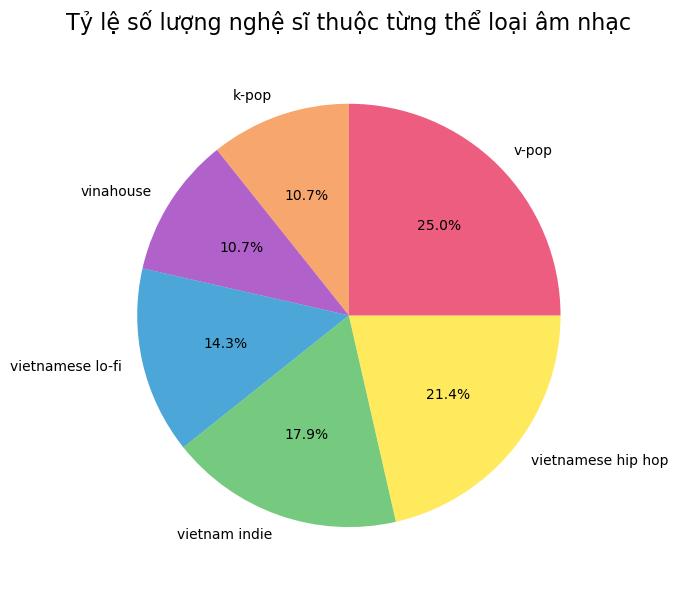

In [49]:
# Chọn dữ liệu của những nghệ sĩ này
df_top_genres = df_exploded[df_exploded['artist_name'].isin(top_artist_names)]

# Đếm số lượng nghệ sĩ duy nhất theo từng thể loại
genre_artist_counts = df_top_genres.groupby('genres')['artist_name'].nunique().sort_values(ascending=True)

# Chỉ lấy top 8 thể loại, gộp phần còn lại thành "Khác"
top_n = 8
top_genres = genre_artist_counts[:top_n]
other_count = genre_artist_counts[top_n:].sum()

# Nếu "Khác" có giá trị, thêm vào danh sách
if other_count > 0:
    top_genres['Khác'] = other_count

# Ánh xạ màu cho Pie Chart theo đúng thể loại
pie_colors = [genre_colors[genre] if genre in genre_colors else "#CCCCCC" for genre in top_genres.index]

# Vẽ Pie Chart với màu chính xác từ Bubble Chart
plt.figure(figsize=(10, 6))
plt.pie(
    top_genres, 
    labels=top_genres.index, 
    autopct='%1.1f%%', 
    startangle=90,  # Bắt đầu từ góc 12h
    colors=pie_colors,  # Sử dụng đúng màu từ Bubble Chart
    wedgeprops={'alpha': 0.7}
)
plt.title("Tỷ lệ số lượng nghệ sĩ thuộc từng thể loại âm nhạc", fontsize=16, pad=15)
plt.tight_layout()
# plt.savefig("q3_2.svg", format="svg")
plt.show()

Từ biểu đồ trên ta thấy:
- Với 25%, V-Pop là thể loại có nhiều nghệ sĩ nhất trong top 10 nghệ sĩ có lượt stream cao nhất. Điều này cho thấy các nghệ sĩ theo đuổi V-Pop đang có vị thế vững chắc trên thị trường âm nhạc Việt Nam.
- Vietnamese Hip-hop chiếm 21.4%, trong khi Vietnam Indie đạt 17.9%, chứng tỏ hai thể loại này đang thu hút sự quan tâm lớn từ cả nghệ sĩ lẫn khán giả. Đây là dấu hiệu cho thấy Hip-hop và Indie đang trở thành xu hướng chính, với ngày càng nhiều nghệ sĩ theo đuổi phong cách này.
- Với 14.3%, Vietnamese Lo-fi có một số lượng nghệ sĩ đáng kể trong top 10, cho thấy dòng nhạc này đang phát triển và thu hút được nhiều người theo đuổi.
- K-Pop và Vinahouse đều có tỷ lệ 10.7%, cho thấy dù không chiếm ưu thế tuyệt đối, hai thể loại này vẫn có nghệ sĩ thành công với lượng stream đáng kể.

**Kết luận**: nhìn chung, có sự trùng khớp đáng kể giữa thể loại nhạc phổ biến nhất và thể loại mà các nghệ sĩ hàng đầu theo đuổi, đặc biệt là với V-Pop, Vietnamese Hip-hop và Vietnam Indie. Tuy nhiên, vẫn có những ngoại lệ như Vietnamese Lo-fi, Vinahouse hay K-Pop, cho thấy rằng một thể loại có nhiều bài hát không đồng nghĩa với việc sẽ có nhiều nghệ sĩ trong top đầu theo đuổi nó.

## Câu hỏi 4: Mối liên hệ và xu hướng của thời gian trụ hạng và lượt stream trung bình theo năm
Một bài hát có thời gian trụ hạng lâu liệu có đồng nghĩa với việc nó đạt được nhiều lượt stream hơn? Hay những bản hit bùng nổ với lượt stream khổng lồ lại nhanh chóng bị thay thế trên bảng xếp hạng?

Bằng cách quan sát xu hướng thời gian trụ hạng trung bình và lượt stream trung bình theo từng năm, chúng ta có thể tìm hiểu xem liệu những bài hát nổi bật có ngày càng giữ vững vị trí lâu hơn hay không, cũng như sự thay đổi trong cách khán giả Việt Nam tiếp cận và lắng nghe âm nhạc trên Spotify.

Biểu đồ dưới đây sẽ giúp chúng ta nhận diện mối quan hệ giữa hai yếu tố này và khám phá những thay đổi trong xu hướng âm nhạc theo thời gian.

Đầu tiên ta lấy ra số năm từ thời gian phát hành

In [51]:
# Trích xuất năm phát hành
df['release_year'] = df['release_date'].dt.year
chosen_df = df.copy()

# Tính trung bình thời gian trụ hạng và tổng lượt stream theo năm
df_yearly = chosen_df.groupby('release_year').agg({'wks': 'mean', 'total_streams': 'mean'}).reset_index()

Sau đó vẽ biểu đồ kết hợp hai trục Y để thể hiện mối quan hệ giữa thời gian trụ hạng và lượt stream trung bình theo năm cũng như xu hướng của chúng

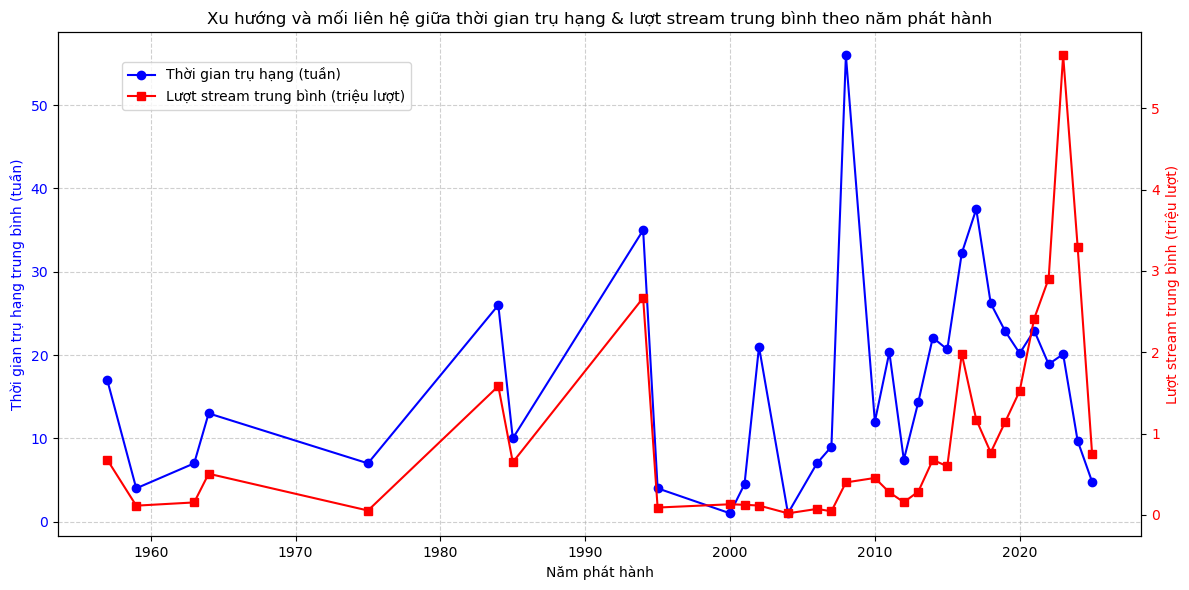

In [52]:
fig, ax1 = plt.subplots(figsize=(12, 6))
# Vẽ đường xu hướng thời gian trụ hạng trung bình (màu xanh)
ax1.plot(df_yearly['release_year'], df_yearly['wks'], marker='o', linestyle='-', color='b', label="Thời gian trụ hạng (tuần)")
ax1.set_xlabel("Năm phát hành")
ax1.set_ylabel("Thời gian trụ hạng trung bình (tuần)", color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, linestyle='--', alpha=0.6)

# Tạo trục Y thứ hai cho lượt stream trung bình
ax2 = ax1.twinx()
ax2.plot(df_yearly['release_year'], df_yearly['total_streams']/1e6, marker='s', linestyle='-', color='r', label="Lượt stream trung bình (triệu lượt)")
ax2.set_ylabel("Lượt stream trung bình (triệu lượt)", color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Thêm tiêu đề và chú thích
plt.title("Xu hướng và mối liên hệ giữa thời gian trụ hạng & lượt stream trung bình theo năm phát hành")
fig.tight_layout()
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
# plt.savefig("q4.svg", format="svg")
plt.show()

Nhận xét

1. Xu hướng theo thời gian

- **Giai đoạn 1960 - 1990**: Thời gian trụ hạng dao động trong khoảng 5 - 20 tuần, không có biến động lớn, và lượt stream trung bình rất thấp, do các nền tảng nhạc số chưa phát triển, dẫn đến việc đo lường lượt nghe gặp nhiều hạn chế.  

- **Giai đoạn 1990 - 2010**: Thời gian trụ hạng bắt đầu tăng nhẹ, có một số đỉnh vào khoảng 1990 và 2000, đạt khoảng 30 tuần trong khi đó lượt stream vẫn chưa có sự bứt phá rõ rệt. Khoảng năm 2000 có sự sụt giảm mạnh cả về thời gian trụ hạng và lượt stream, có thể do thay đổi trong xu hướng tiêu thụ âm nhạc.  

- **Giai đoạn 2010 - 2025**: Thời gian trụ hạng có xu hướng tăng, đạt 50 tuần vào một số năm, lượt stream tăng đột biến sau năm 2015, đạt mức hơn 5 triệu lượt vào một số năm gần đây. Xu hướng này có thể liên quan đến sự phát triển mạnh mẽ của Spotify, Apple Music, YouTube và các nền tảng nhạc số khác.

2. Mối liên hệ giữa thời gian trụ hạng và lượt stream
- Trước năm 2000, thời gian trụ hạng và lượt stream không có mối quan hệ rõ ràng, do lượt stream bị giới hạn bởi công nghệ.  
- Từ năm 2010 trở đi, mối quan hệ trở nên chặt chẽ hơn:  
    - Khi lượt stream tăng, thời gian trụ hạng cũng có xu hướng tăng theo.  
    - Điều này cho thấy rằng các bài hát phổ biến trên nền tảng nhạc số có thể duy trì sức hút lâu hơn, giúp chúng tồn tại lâu trên bảng xếp hạng.  
    - Ngược lại, một số bài hát có thời gian trụ hạng dài nhưng không có lượt stream quá cao, có thể là do chúng phổ biến vào thời điểm phát hành nhưng không duy trì được sự quan tâm lâu dài.  

**Kết luận**: có **mối quan hệ gián tiếp** giữa **thời gian trụ hạng và lượt stream trung bình**, nhưng mối quan hệ này thay đổi theo thời gian. Trước đây, bài hát có thời gian trụ hạng lâu thường có nhiều lượt stream, nhưng hiện tại, các bài hát có thể đạt lượt stream cao trong thời gian ngắn mà không cần trụ hạng lâu trên bảng xếp hạng.


## Câu hỏi 5: Xu hướng phát hành và lượt streams trung bình của các bài hát theo thời gian ở thị trường âm nhạc Việt Nam như nào?

Ngành công nghiệp âm nhạc không ngừng thay đổi, kéo theo sự biến động trong thời điểm phát hành và mức độ thành công của các ca khúc. Một số nghệ sĩ chọn phát hành nhạc vào đầu năm để tạo đà, trong khi số khác tận dụng mùa cao điểm cuối năm để thu hút sự chú ý. Nhưng liệu có quy luật nào rõ ràng trong cách các bài hát được phát hành và mức độ đón nhận của khán giả không?

Khi chia thời gian thành 4 quý trong năm, ta có thể quan sát:

Quý nào chứng kiến số lượng bài hát phát hành nhiều nhất?
Quý nào có lượt streams trung bình cao nhất? Liệu số lượng phát hành và mức độ thành công có mối tương quan với nhau?
Có giai đoạn nào trong năm đặc biệt thuận lợi cho các bài hát bùng nổ trên thị trường không?

In [53]:
# Tính tổng lượt stream theo tháng và năm
top_song_df = df.copy()
top_song_df['release_month'] = top_song_df['release_date'].dt.month
top_song_df['release_year'] = top_song_df['release_date'].dt.year

df_unique_tracks = top_song_df.drop_duplicates(subset=['track_name', 'release_month', 'release_year'])

monthly_counts = df_unique_tracks['release_month'].value_counts().sort_index()
monthly_avg_streams = df_unique_tracks.groupby('release_month')['total_streams'].mean().sort_index()

# Chia dữ liệu theo quý
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
monthly_counts.index = pd.cut(monthly_counts.index, bins=[0, 3, 6, 9, 12], labels=quarters, right=True)
monthly_avg_streams.index = pd.cut(monthly_avg_streams.index, bins=[0, 3, 6, 9, 12], labels=quarters, right=True)

quarterly_counts = monthly_counts.groupby(monthly_counts.index).sum()
quarterly_avg_streams = monthly_avg_streams.groupby(monthly_avg_streams.index).mean()

Vẽ biểu đồ cột so sánh số lượng bài hát và lượt stream trung bình mỗi quý

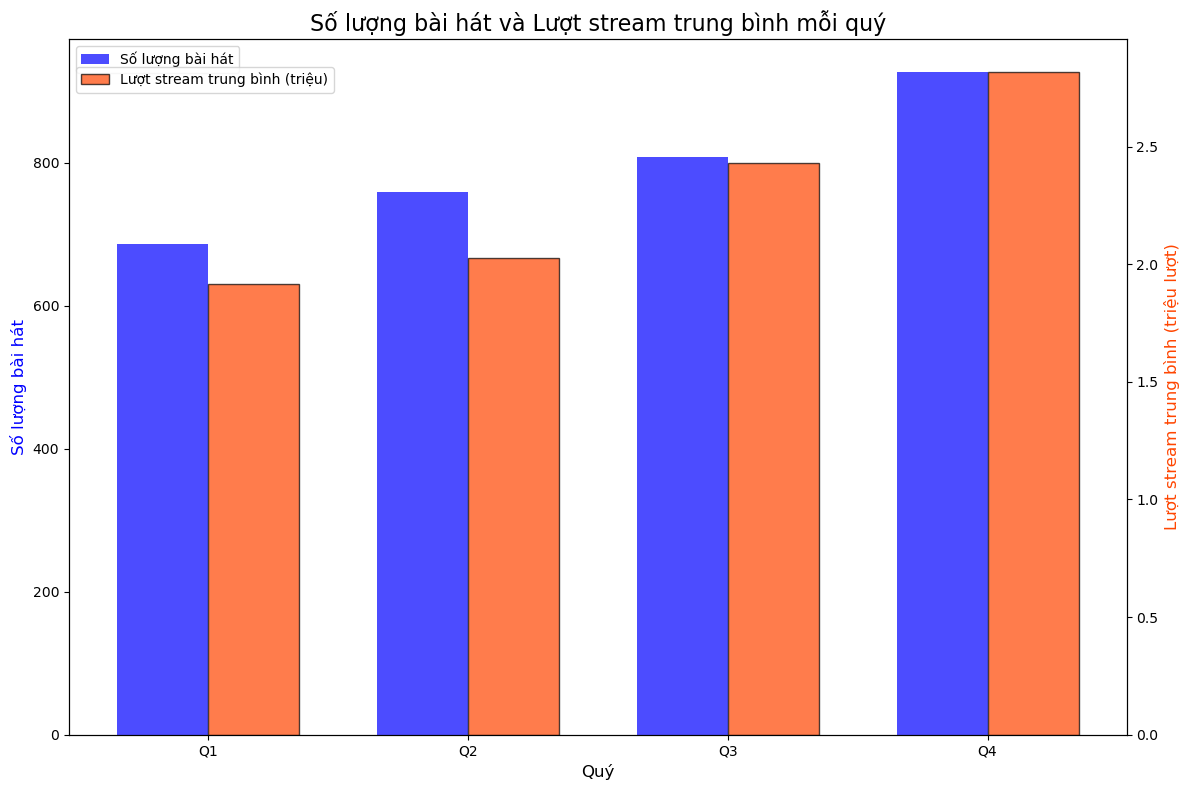

In [54]:
fig, ax1 = plt.subplots(figsize=(12, 8))

bar_width = 0.35
index = range(len(quarters))

bar1 = ax1.bar(index, quarterly_counts.values, bar_width, label='Số lượng bài hát', color='#0000FF',  alpha=0.7)

ax1.set_xlabel('Quý', fontsize=12)
ax1.set_ylabel('Số lượng bài hát', fontsize=12, color='#0000FF')
ax1.set_title('Số lượng bài hát và Lượt stream trung bình mỗi quý', fontsize=16)
ax1.set_xticks([i + bar_width / 2 for i in index])
ax1.set_xticklabels(quarters)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
bar2 = ax2.bar([i + bar_width for i in index], (quarterly_avg_streams.values / 1e6), bar_width, label='Lượt stream trung bình (triệu)', color='#FF4500', edgecolor='black', alpha=0.7)

ax2.set_ylabel('Lượt stream trung bình (triệu lượt)', fontsize=12, color='#FF4500')
ax2.legend(loc='upper left', bbox_to_anchor=(0, 0.97))
plt.tight_layout()
# plt.savefig("q5.svg", format="svg")
plt.show()

Nhận xét:
1. Xu hướng phát hành bài hát theo thời gian
    - **Quý 1 - Quý 2:** Số lượng bài hát phát hành trong hai quý đầu năm tương đối thấp. Điều này có thể phản ánh việc các nghệ sĩ và nhà sản xuất chưa tập trung vào giai đoạn này do đây chưa phải là thời điểm cao trào của thị trường âm nhạc.  
    - **Quý 3:** Số lượng bài hát phát hành tăng rõ rệt, cho thấy thị trường âm nhạc trở nên sôi động hơn. Đây có thể là thời điểm các nghệ sĩ bắt đầu chuẩn bị cho những dự án âm nhạc lớn vào cuối năm.  
    - **Quý 4:** Ghi nhận số lượng bài hát phát hành cao nhất, có thể do nghệ sĩ tận dụng mùa lễ hội và cuối năm – thời điểm người nghe có nhu cầu giải trí cao, giúp bài hát có cơ hội bùng nổ hơn.  

2. Mối liên hệ giữa số lượng bài hát phát hành và lượt streams trung bình
    - **Nửa đầu năm (Quý 1 - Quý 2):** Lượt streams trung bình có xu hướng thấp hơn, tương ứng với số lượng bài hát phát hành ít hơn. Điều này gợi ý rằng thị trường âm nhạc có thể chưa thực sự sôi động vào đầu năm.  
    - **Nửa cuối năm (Quý 3 - Quý 4):** Khi số lượng bài hát phát hành tăng mạnh, lượt streams trung bình cũng có xu hướng tăng theo. Điều này cho thấy thị trường âm nhạc hoạt động mạnh mẽ hơn vào giai đoạn này, với sự quan tâm lớn hơn từ khán giả.  
    - **Mối quan hệ thuận giữa hai yếu tố:** Số lượng bài hát phát hành và lượt streams trung bình có xu hướng tăng cùng nhau. Khi có nhiều bài hát mới ra mắt, người nghe cũng có xu hướng tiếp cận và nghe nhạc nhiều hơn, góp phần làm tăng mức streams trung bình.  

3. **Kết luận**: Xu hướng phát hành bài hát và mức độ thành công có sự thay đổi theo từng giai đoạn trong năm. Nửa cuối năm, đặc biệt là Quý 3 và Quý 4, là thời điểm thị trường nhạc trở nên sôi động nhất với số lượng phát hành cao và lượt streams trung bình đạt đỉnh. Điều này có thể do tác động của mùa lễ hội, chiến lược tiếp cận khán giả của nghệ sĩ, hoặc xu hướng nghe nhạc của công chúng.

## Câu hỏi 6: Xu hướng phát hành bài hát tại Việt Nam thay đổi như thế nào theo thời gian?

Âm nhạc không chỉ là tấm gương phản chiếu thị hiếu của khán giả Việt Nam mà còn thể hiện sự phát triển của công nghệ và cách thức phân phối trong thị trường âm nhạc trong nước. Trước đây, việc phát hành bài hát tại Việt Nam thường phụ thuộc vào các hãng thu âm truyền thống, với quy trình sản xuất đĩa nhạc và phân phối qua các cửa hàng bán lẻ, đòi hỏi thời gian và nguồn lực đáng kể. Tuy nhiên, sự xuất hiện của các nền tảng số như Spotify tại Việt Nam từ năm 2018 đã mang đến một cuộc cách mạng, cho phép nghệ sĩ phát hành và tiếp cận khán giả nhanh chóng hơn bao giờ hết. Vậy, xu hướng phát hành bài hát tại Việt Nam đã thay đổi cụ thể như thế nào theo thời gian, và điều này phản ánh gì về sự phát triển của thị trường âm nhạc trong nước?

Đếm số lượng bài hát được ra mắt hằng năm

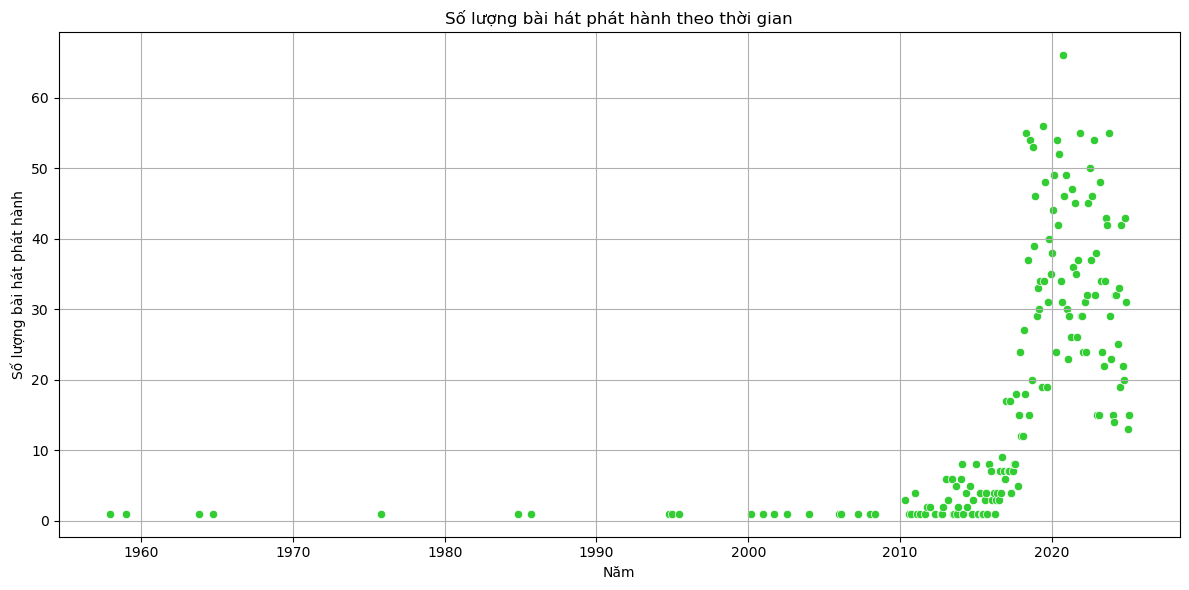

In [55]:
tracks_per_month = df.groupby(df['release_date'].dt.to_period('M')).size()
plt.figure(figsize=(12, 6))
plt.scatter(tracks_per_month.index.to_timestamp(), tracks_per_month.values, color ="#32CD32", alpha=1, edgecolors='w', linewidth=0.5)
plt.title('Số lượng bài hát phát hành theo thời gian')
plt.xlabel('Năm')
plt.ylabel('Số lượng bài hát phát hành')
plt.grid(True)
plt.tight_layout()
# plt.savefig('q6.svg')
plt.show()

Nhận xét kết quả từ biểu đồ  
- Trước năm 2010, số lượng bài hát trong top các bài hát được nghe nhiều nhất trên Spotify tại Việt Nam rất hạn chế, phản ánh quy trình phát hành truyền thống qua hãng thu âm và đĩa vật lý.  
- Từ năm 2010, số lượng bài hát top tăng dần, và bùng nổ từ 2018 – khi Spotify thâm nhập Việt Nam – với 20-60 bài mỗi năm, cho thấy ảnh hưởng của nền tảng số trong việc thúc đẩy các bài hit nổi bật.  
- Xu hướng này phản ánh sự chuyển đổi của thị trường âm nhạc Việt Nam sang kỷ nguyên số, nơi nghệ sĩ dễ dàng phát hành và khán giả có thể dễ dàng tiếp cận do đó các bài hát càng về sau càng có được các lượt stream cao hơn.